# 09 — Temporal Recovery Tracking

Compute per-parcel recovery scores (0→1) at each post-fire observation date using
two complementary sensor signals, producing a frontend-ready parquet that feeds
into the existing pipeline output layer.

**Recovery score = 0.5 × NDVI_recovery + 0.5 × InSAR_recovery**
- **NDVI recovery**: spectral vegetation regrowth ratio (Landsat 30m)
- **InSAR recovery**: coherence ratio from 12-day Sentinel-1 CSLC pairs (5m×10m) — structural stability

Visual recovery (laplacian variance from ESRI Wayback crops) was tested but provides
no class separation — parcel-masked texture at 30cm is either too noisy (small parcels)
or too homogeneous (large parcels), producing ~0.99 for all classes. Dropped in favor
of the two signals with actual discriminative power.

In [1]:
import io
import json
import math
import time
import warnings
from pathlib import Path

import cv2
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer
import pystac_client
import rasterio
import requests
from PIL import Image
from rasterio.transform import from_bounds as affine_from_bounds
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
from rasterstats import zonal_stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="rasterstats")

DATA_RAW = Path("../data/raw")
DATA_PROC = Path("../data/processed")
DATA_RESULTS = Path("../data/results")
DATA_RESULTS.mkdir(parents=True, exist_ok=True)

AOI_BBOX = [-105.16, 39.93, -105.07, 40.01]

print("Imports OK")

Imports OK


## 1 — Load Baselines

In [2]:
# Load damage predictions from notebook 08
pred_df = pd.read_parquet(DATA_RESULTS / "damage_classifier_predictions.parquet")
print(f"Predictions: {len(pred_df):,} rows, columns: {list(pred_df.columns)}")

# Load ground truth parcels
gdf_all = gpd.read_file(DATA_RAW / "ground_truth" / "marshall_fire_damage_parcels.geojson")
gdf = gdf_all[gdf_all["Condition"].isin(["Destroyed", "Damaged", "Unaffected"])].copy()
print(f"Filtered to {len(gdf):,} parcels with known condition ({gdf['ParcelNo'].nunique():,} unique)")

# Deduplicate: keep worst severity per ParcelNo (Destroyed > Damaged > Unaffected)
severity = {"Destroyed": 0, "Damaged": 1, "Unaffected": 2}
gdf["_severity"] = gdf["Condition"].map(severity)
gdf = gdf.sort_values("_severity").drop_duplicates(subset="ParcelNo", keep="first").drop(columns="_severity")
gdf = gdf.reset_index(drop=True)
print(f"After dedup: {len(gdf):,} parcels")
print(gdf["Condition"].value_counts())

# Merge damage predictions onto gdf (left join on ParcelNo)
gdf = gdf.merge(
    pred_df[["ParcelNo", "xgb_pred", "prob_Destroyed", "prob_Damaged", "prob_Unaffected"]],
    on="ParcelNo",
    how="left",
)
print(f"\nParcels with predictions: {gdf['xgb_pred'].notna().sum():,} / {len(gdf):,}")

Predictions: 1,793 rows, columns: ['ParcelNo', 'Condition', 'fold', 'xgb_pred', 'prob_Destroyed', 'prob_Damaged', 'prob_Unaffected']
Filtered to 1,950 parcels with known condition (1,793 unique)
After dedup: 1,793 parcels
Condition
Destroyed     1093
Unaffected     464
Damaged        236
Name: count, dtype: int64

Parcels with predictions: 1,793 / 1,793


In [3]:
OBSERVATION_DATES = ["2022-01", "2022-06", "2023-06", "2024-06"]
MONTHS_POST = {"2022-01": 1, "2022-06": 6, "2023-06": 18, "2024-06": 30}

## 2 — NDVI Recovery Ratio

In [4]:
# Planetary Computer catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)


def search_landsat(date_range, bbox=AOI_BBOX, max_cloud=10):
    """Search for Landsat C2 L2 scenes."""
    search = catalog.search(
        collections=["landsat-c2-l2"],
        bbox=bbox,
        datetime=date_range,
        query={"eo:cloud_cover": {"lt": max_cloud}},
    )
    items = list(search.items())
    print(f"Found {len(items)} Landsat scenes for {date_range}")
    for item in items:
        print(f"  {item.id}  cloud={item.properties.get('eo:cloud_cover', '?')}%")
    return items


def read_landsat_bands(item, bands, bbox=AOI_BBOX):
    """Read bands from a Landsat item, windowed to bbox. Returns dict + transform."""
    result = {}
    transform_out = None
    SR_SCALE, SR_OFFSET = 0.0000275, -0.174

    for band_name in bands:
        href = planetary_computer.sign(item.assets[band_name].href)
        with rasterio.open(href) as src:
            bounds_native = transform_bounds("EPSG:4326", src.crs, *bbox)
            window = from_bounds(*bounds_native, transform=src.transform)
            data = src.read(1, window=window).astype(np.float32)
            if transform_out is None:
                transform_out = src.window_transform(window)
            data = data * SR_SCALE + SR_OFFSET
            data = np.clip(data, 0, 1)
            result[band_name] = data
            print(f"  {band_name}: shape={data.shape}, range=[{data.min():.4f}, {data.max():.4f}]")
    return result, transform_out


def safe_ratio(a, b):
    """Compute (a-b)/(a+b) safely."""
    denom = a + b
    return np.where(denom != 0, (a - b) / denom, 0.0).astype(np.float32)


print("Landsat functions defined.")

Landsat functions defined.


In [5]:
# Define search date ranges for each observation period
SEARCH_RANGES = {
    "pre":     "2021-10-01/2021-11-30",
    "2022-01": "2022-01-01/2022-02-28",
    "2022-06": "2022-06-01/2022-07-31",
    "2023-06": "2023-06-01/2023-07-31",
    "2024-06": "2024-06-01/2024-07-31",
}

BANDS = ["nir08", "red"]

# Compute NDVI for all dates (pre-fire + each post-fire observation)
ndvi_rasters = {}  # key -> (ndvi_array, affine_transform)

for date_key, date_range in SEARCH_RANGES.items():
    print(f"\n--- {date_key} ({date_range}) ---")
    items = search_landsat(date_range)
    if not items:
        print(f"  WARNING: no scenes found for {date_key}, skipping")
        continue

    item = items[0]
    print(f"  Using: {item.id}")
    bands, _ = read_landsat_bands(item, BANDS)

    ndvi = safe_ratio(bands["nir08"], bands["red"])
    # Build affine transform from AOI bbox to match raster shape
    h, w = ndvi.shape
    aff = affine_from_bounds(*AOI_BBOX, w, h)
    ndvi_rasters[date_key] = (ndvi, aff)
    print(f"  NDVI shape={ndvi.shape}, range=[{ndvi.min():.4f}, {ndvi.max():.4f}]")

print(f"\nComputed NDVI for {len(ndvi_rasters)} dates: {list(ndvi_rasters.keys())}")


--- pre (2021-10-01/2021-11-30) ---
Found 9 Landsat scenes for 2021-10-01/2021-11-30
  LC09_L2SP_034032_20211122_02_T1  cloud=2.7%
  LE07_L2SP_033032_20211111_02_T1  cloud=2.0%
  LC09_L2SP_033033_20211107_02_T1  cloud=0.1%
  LC09_L2SP_033032_20211107_02_T1  cloud=0.91%
  LC08_L2SP_033032_20211103_02_T1  cloud=2.3%
  LC08_L2SP_033032_20211018_02_T1  cloud=6.12%
  LE07_L2SP_034032_20211017_02_T1  cloud=0.0%
  LE07_L2SP_033032_20211010_02_T1  cloud=4.0%
  LC08_L2SP_033032_20211002_02_T1  cloud=1.19%
  Using: LC09_L2SP_034032_20211122_02_T1
  nir08: shape=(296, 257), range=[0.0105, 1.0000]
  red: shape=(296, 257), range=[0.0268, 1.0000]
  NDVI shape=(296, 257), range=[-0.5764, 0.8114]

--- 2022-01 (2022-01-01/2022-02-28) ---
Found 7 Landsat scenes for 2022-01-01/2022-02-28
  LC08_L2SP_034032_20220214_02_T1  cloud=4.51%
  LC08_L2SP_033032_20220207_02_T1  cloud=0.53%
  LC09_L2SP_033032_20220130_02_T1  cloud=3.81%
  LE07_L2SP_033032_20220130_02_T1  cloud=2.0%
  LC08_L2SP_034032_20220129_02_T

/var/folders/zq/f6zc6fz576799p8z3wp0kl6h0000gn/T/ipykernel_85024/2377299755.py:47: RuntimeWarning: invalid value encountered in divide
  return np.where(denom != 0, (a - b) / denom, 0.0).astype(np.float32)


  nir08: shape=(296, 257), range=[0.0511, 0.7867]
  red: shape=(296, 257), range=[0.0495, 0.7536]
  NDVI shape=(296, 257), range=[-0.2028, 0.8095]

--- 2023-06 (2023-06-01/2023-07-31) ---
Found 8 Landsat scenes for 2023-06-01/2023-07-31
  LE07_L2SP_034032_20230717_02_T1  cloud=0.0%
  LC09_L2SP_033032_20230712_02_T1  cloud=2.01%
  LE07_L2SP_033032_20230712_02_T1  cloud=2.0%
  LC08_L2SP_034032_20230711_02_T1  cloud=0.34%
  LC09_L2SP_034032_20230703_02_T1  cloud=1.97%
  LC08_L2SP_034032_20230625_02_T1  cloud=1.71%
  LC08_L2SP_033032_20230618_02_T1  cloud=8.4%
  LC09_L2SP_033032_20230610_02_T1  cloud=8.16%
  Using: LE07_L2SP_034032_20230717_02_T1
  nir08: shape=(296, 257), range=[0.0000, 0.7071]
  red: shape=(296, 257), range=[0.0000, 1.0000]
  NDVI shape=(296, 257), range=[-0.3007, 0.8424]

--- 2024-06 (2024-06-01/2024-07-31) ---
Found 8 Landsat scenes for 2024-06-01/2024-07-31
  LC09_L2SP_033032_20240730_02_T1  cloud=0.01%
  LC08_L2SP_034032_20240729_02_T1  cloud=0.05%
  LC08_L2SP_033032

In [6]:
# Compute NDVI recovery ratio per parcel per date
# ndvi_recovery = (NDVI_t - NDVI_post) / (NDVI_pre - NDVI_post)
# When denominator ≈ 0 (no fire damage), parcel is already recovered → 1.0
# Clip to [0, 2] (allow >1 for exceeded baseline)

parcels_4326 = gdf.to_crs("EPSG:4326")

# Get pre-fire and immediate post-fire (Jan 2022) NDVI zonal means
ndvi_pre_arr, ndvi_pre_aff = ndvi_rasters["pre"]
ndvi_post_arr, ndvi_post_aff = ndvi_rasters["2022-01"]

pre_stats = zonal_stats(parcels_4326.geometry, ndvi_pre_arr, affine=ndvi_pre_aff, stats=["mean"], nodata=np.nan)
post_stats = zonal_stats(parcels_4326.geometry, ndvi_post_arr, affine=ndvi_post_aff, stats=["mean"], nodata=np.nan)

ndvi_pre_vals = np.array([s["mean"] if s["mean"] is not None else np.nan for s in pre_stats])
ndvi_post_vals = np.array([s["mean"] if s["mean"] is not None else np.nan for s in post_stats])

# Compute recovery ratio for each observation date
ndvi_records = []

for date_key in OBSERVATION_DATES:
    if date_key not in ndvi_rasters:
        print(f"  Skipping {date_key} — no NDVI raster available")
        continue

    ndvi_t_arr, ndvi_t_aff = ndvi_rasters[date_key]
    t_stats = zonal_stats(parcels_4326.geometry, ndvi_t_arr, affine=ndvi_t_aff, stats=["mean"], nodata=np.nan)
    ndvi_t_vals = np.array([s["mean"] if s["mean"] is not None else np.nan for s in t_stats])

    # Recovery ratio: how much of the pre→post drop has been regained
    denom = ndvi_pre_vals - ndvi_post_vals
    # If pre ≈ post (no fire damage), parcel never lost NDVI → fully recovered (1.0)
    with np.errstate(divide="ignore", invalid="ignore"):
        recovery = np.where(
            np.abs(denom) > 1e-6,
            (ndvi_t_vals - ndvi_post_vals) / denom,
            1.0,
        )
    recovery = np.clip(recovery, 0, 2)

    for i, pno in enumerate(gdf["ParcelNo"]):
        ndvi_records.append({
            "ParcelNo": pno,
            "date": date_key,
            "ndvi_recovery": float(recovery[i]) if np.isfinite(recovery[i]) else np.nan,
        })

ndvi_df = pd.DataFrame(ndvi_records)
print(f"NDVI recovery records: {len(ndvi_df):,}")

# Print mean NDVI recovery by class × date
ndvi_merged = ndvi_df.merge(gdf[["ParcelNo", "Condition"]], on="ParcelNo", how="left")
print("\nMean NDVI recovery by class × date:")
print(ndvi_merged.groupby(["Condition", "date"])["ndvi_recovery"].mean().unstack().round(3))

NDVI recovery records: 7,172

Mean NDVI recovery by class × date:
date        2022-01  2022-06  2023-06  2024-06
Condition                                     
Damaged       0.627    1.079    1.079    1.113
Destroyed     0.813    0.950    0.906    0.949
Unaffected    0.787    1.102    0.862    1.149


## 2b — InSAR Coherence Full Time Series (Costco-normalized)

Instead of sampling 4 snapshot dates, we compute **all 126 consecutive 12-day pairs**
from Sep 2021 → Dec 2025 and normalize each by the Costco parking lot (parcel 157713021001).

NB04c proved this approach: the full Costco-normalized time series clearly shows
recovery trajectories — pre-fire all classes at ~0.90–0.95× Costco, Destroyed drops
to ~0.50× at the fire, then gradually recovers over 2–3 years.

This gives us enough temporal resolution to detect per-parcel recovery dates via
change detection on the smoothed normalized coherence series.

In [7]:
# Compute InSAR coherence for ALL consecutive 12-day pairs (reuse NB04c approach)
# ~127 CSLC acquisitions → ~126 pairs, ~3s each ≈ ~6 min total

import h5py
from datetime import datetime as dt_class
from scipy.ndimage import uniform_filter
from pyproj import Transformer
from rasterio.transform import Affine

CSLC_DIR = DATA_RAW / "sentinel1" / "cslc"
FIRE_DATE = dt_class(2021, 12, 30)

# Wider AOI for CSLC — must include Costco at (-105.1742, 39.9597)
AOI_CSLC = [-105.23, 39.915, -105.12, 39.98]
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32613", always_xy=True)
aoi_west, aoi_south = to_utm.transform(AOI_CSLC[0], AOI_CSLC[1])
aoi_east, aoi_north = to_utm.transform(AOI_CSLC[2], AOI_CSLC[3])
aoi_bounds_cslc = (aoi_west, aoi_south, aoi_east, aoi_north)

# Discover all CSLC files and parse dates
h5_files = sorted(CSLC_DIR.glob("OPERA_L2_CSLC-S1_T056-118973-IW1_*.h5"))

def parse_date(p):
    """Extract acquisition date from OPERA CSLC filename."""
    for part in p.stem.split("_"):
        if part.startswith("20") and "T" in part and part.endswith("Z"):
            return dt_class.strptime(part[:8], "%Y%m%d")
    raise ValueError(f"Cannot parse date from {p.name}")

dates_files = sorted([(parse_date(f), f) for f in h5_files], key=lambda x: x[0])
pairs = [(dates_files[i], dates_files[i+1]) for i in range(len(dates_files)-1)]
print(f"Found {len(dates_files)} CSLC acquisitions → {len(pairs)} consecutive pairs")


def load_cslc_chip(h5_path, aoi_bounds):
    """Load a complex SLC chip from an OPERA CSLC HDF5 file, clipped to AOI."""
    w, s, e, n = aoi_bounds
    with h5py.File(h5_path, "r") as f:
        x = f["/data/x_coordinates"][:]
        y = f["/data/y_coordinates"][:]
        col_mask = (x >= w) & (x <= e)
        row_mask = (y >= s) & (y <= n)
        c0, c1 = np.where(col_mask)[0][[0, -1]]
        r0, r1 = np.where(row_mask)[0][[0, -1]]
        slc = f["/data/VV"][r0:r1+1, c0:c1+1]
        x_chip = x[c0:c1+1]
        y_chip = y[r0:r1+1]
    return slc, x_chip, y_chip


def compute_coherence(slc1, slc2, win=5):
    """Estimate interferometric coherence with a uniform spatial averaging window."""
    s1 = np.where(np.isfinite(slc1), slc1, 0)
    s2 = np.where(np.isfinite(slc2), slc2, 0)
    cross_real = uniform_filter(np.real(s1 * np.conj(s2)), win)
    cross_imag = uniform_filter(np.imag(s1 * np.conj(s2)), win)
    cross = cross_real + 1j * cross_imag
    pow1 = uniform_filter(np.abs(s1)**2, win)
    pow2 = uniform_filter(np.abs(s2)**2, win)
    denom = np.sqrt(pow1 * pow2)
    coh = np.where(denom > 0, np.abs(cross) / denom, 0)
    valid = np.isfinite(slc1) & np.isfinite(slc2)
    coh[~valid] = np.nan
    return coh.astype(np.float32)


# Compute all consecutive coherence maps
print(f"Computing coherence for {len(pairs)} pairs...")
coherence_maps = []
pair_labels = []
pair_mid_dates = []
pair_dates = []  # (date1, date2) tuples

for idx, ((dt1, f1), (dt2, f2)) in enumerate(pairs):
    label = f"{dt1.strftime('%Y-%m-%d')} → {dt2.strftime('%Y-%m-%d')}"
    slc1, x_coords, y_coords = load_cslc_chip(f1, aoi_bounds_cslc)
    slc2, _, _ = load_cslc_chip(f2, aoi_bounds_cslc)
    coh = compute_coherence(slc1, slc2, win=5)
    coherence_maps.append(coh)
    pair_labels.append(label)
    pair_mid_dates.append(dt1 + (dt2 - dt1) / 2)
    pair_dates.append((dt1, dt2))
    if (idx + 1) % 10 == 0 or idx == len(pairs) - 1:
        print(f"  [{idx+1}/{len(pairs)}] {label}  mean={np.nanmean(coh):.3f}")

n_pairs = len(coherence_maps)
print(f"\nDone. {n_pairs} coherence maps computed.")

Found 127 CSLC acquisitions → 126 consecutive pairs
Computing coherence for 126 pairs...
  [10/126] 2021-12-31 → 2022-01-12  mean=0.394
  [20/126] 2022-04-30 → 2022-05-12  mean=0.536
  [30/126] 2022-08-28 → 2022-09-09  mean=0.468
  [40/126] 2023-01-19 → 2023-02-12  mean=0.342
  [50/126] 2023-05-31 → 2023-06-12  mean=0.405
  [60/126] 2023-09-28 → 2023-10-10  mean=0.574
  [70/126] 2024-01-26 → 2024-02-07  mean=0.332
  [80/126] 2024-05-25 → 2024-06-06  mean=0.495
  [90/126] 2024-09-22 → 2024-10-04  mean=0.374
  [100/126] 2025-01-20 → 2025-02-01  mean=0.379
  [110/126] 2025-05-20 → 2025-06-01  mean=0.468
  [120/126] 2025-09-29 → 2025-10-11  mean=0.493
  [126/126] 2025-12-10 → 2025-12-22  mean=0.567

Done. 126 coherence maps computed.


In [8]:
# Zonal stats + Costco normalization for all 126 pairs (match NB04c approach)
from shapely.geometry import box as shapely_box

COSTCO_PARCEL = "157713021001"
MIN_COH_PIXELS = 3

# Build affine transform from pixel coordinates (same grid for all maps)
dx = x_coords[1] - x_coords[0]
dy = y_coords[1] - y_coords[0]
coh_transform = Affine(dx, 0, x_coords[0] - dx/2, 0, dy, y_coords[0] - dy/2)

# Load parcels in UTM and filter to CSLC coverage
parcels_utm = gdf.to_crs(epsg=32613)
cslc_box = shapely_box(*aoi_bounds_cslc)
in_cslc = parcels_utm.intersects(cslc_box)
print(f"Parcels within CSLC coverage: {in_cslc.sum()} / {len(parcels_utm)}")

# Load Costco parcel
all_parcels_gt = gpd.read_file(DATA_RAW / "ground_truth" / "marshall_fire_damage_parcels.geojson")
costco_gdf = all_parcels_gt[all_parcels_gt["ParcelNo"] == COSTCO_PARCEL].to_crs(epsg=32613)

# Pre-allocate arrays instead of adding columns one-by-one (avoids fragmentation warning)
n_parcels_total = len(parcels_utm)
coh_array = np.full((n_parcels_total, n_pairs), np.nan, dtype=np.float32)
cnt_array = np.zeros((n_parcels_total, n_pairs), dtype=np.int32)
costco_coh = []

print(f"Computing zonal stats for {n_pairs} pairs × {n_parcels_total} parcels...")
conditions = ["Destroyed", "Damaged", "Unaffected"]
cond_masks = {c: (parcels_utm["Condition"] == c).values for c in conditions}

for i, coh_map in enumerate(coherence_maps):
    # Costco reference
    cs = zonal_stats(costco_gdf.geometry, coh_map, affine=coh_transform,
                     stats=["mean"], nodata=np.nan)
    costco_coh.append(cs[0]["mean"] if cs[0]["mean"] else np.nan)

    # Per-parcel zonal stats
    stats = zonal_stats(parcels_utm.geometry, coh_map, affine=coh_transform,
                        stats=["mean", "count"], nodata=np.nan)
    for j, s in enumerate(stats):
        coh_array[j, i] = s["mean"] if s["mean"] is not None else np.nan
        cnt_array[j, i] = s["count"] if s["count"] is not None else 0

    # Mask parcels with <3 pixels
    coh_array[cnt_array[:, i] < MIN_COH_PIXELS, i] = np.nan

    if (i + 1) % 10 == 0 or i == n_pairs - 1:
        class_means = {c: np.nanmean(coh_array[cond_masks[c], i]) for c in conditions}
        print(f"  [{i+1}/{n_pairs}] Costco={costco_coh[i]:.3f}  "
              f"Dest={class_means['Destroyed']:.3f}  "
              f"Dmg={class_means['Damaged']:.3f}  "
              f"Unaff={class_means['Unaffected']:.3f}")

# Assign all columns at once via concat (no fragmentation)
coh_df = pd.DataFrame(coh_array, columns=[f"coh_{i}" for i in range(n_pairs)], index=parcels_utm.index)
cnt_df = pd.DataFrame(cnt_array, columns=[f"cnt_{i}" for i in range(n_pairs)], index=parcels_utm.index)
parcels_utm = pd.concat([parcels_utm, coh_df, cnt_df], axis=1)

costco_arr = np.array(costco_coh)
costco_safe = np.where(costco_arr > 0.01, costco_arr, np.nan)

# Build normalized coherence matrix: (n_parcels, n_pairs)
raw_matrix = coh_array  # already a numpy array
norm_matrix = raw_matrix / costco_safe[np.newaxis, :]

print(f"\nNormalized matrix shape: {norm_matrix.shape}")
print(f"Costco coherence range: {np.nanmin(costco_arr):.3f} – {np.nanmax(costco_arr):.3f}")

# Sanity check: first and last 3 pairs
for label, idxs in [("First 3", range(3)), ("Last 3", range(n_pairs-3, n_pairs))]:
    print(f"\n{label} pairs — mean normalized coherence by class:")
    for c in conditions:
        vals = [np.nanmean(norm_matrix[cond_masks[c], i]) for i in idxs]
        print(f"  {c:12s}: {['%.3f' % v for v in vals]}")

Parcels within CSLC coverage: 1664 / 1793
Computing zonal stats for 126 pairs × 1793 parcels...
  [10/126] Costco=0.606  Dest=0.397  Dmg=0.564  Unaff=0.549
  [20/126] Costco=0.654  Dest=0.571  Dmg=0.648  Unaff=0.624
  [30/126] Costco=0.615  Dest=0.462  Dmg=0.587  Unaff=0.554
  [40/126] Costco=0.408  Dest=0.315  Dmg=0.392  Unaff=0.370
  [50/126] Costco=0.644  Dest=0.431  Dmg=0.543  Unaff=0.540
  [60/126] Costco=0.714  Dest=0.527  Dmg=0.667  Unaff=0.640
  [70/126] Costco=0.422  Dest=0.360  Dmg=0.406  Unaff=0.393
  [80/126] Costco=0.696  Dest=0.605  Dmg=0.619  Unaff=0.601
  [90/126] Costco=0.573  Dest=0.502  Dmg=0.488  Unaff=0.463
  [100/126] Costco=0.395  Dest=0.422  Dmg=0.415  Unaff=0.404
  [110/126] Costco=0.639  Dest=0.649  Dmg=0.598  Unaff=0.586
  [120/126] Costco=0.631  Dest=0.646  Dmg=0.619  Unaff=0.593
  [126/126] Costco=0.722  Dest=0.728  Dmg=0.691  Unaff=0.654

Normalized matrix shape: (1793, 126)
Costco coherence range: 0.318 – 0.750

First 3 pairs — mean normalized coherence b

In [9]:
# Save full per-parcel coherence time series as long-format parquet
# One row per parcel × pair: ~1,577 parcels × 126 pairs ≈ ~199K rows

records = []
parcel_nos = parcels_utm["ParcelNo"].values
parcel_conditions = parcels_utm["Condition"].values

for i in range(n_pairs):
    d1, d2 = pair_dates[i]
    mid = pair_mid_dates[i]
    months_post = (mid - FIRE_DATE).days / 30.44
    costco_val = costco_coh[i]
    for j in range(len(parcel_nos)):
        raw = parcels_utm[f"coh_{i}"].iloc[j]
        records.append({
            "ParcelNo": parcel_nos[j],
            "pair_idx": i,
            "date1": d1.strftime("%Y-%m-%d"),
            "date2": d2.strftime("%Y-%m-%d"),
            "mid_date": mid.strftime("%Y-%m-%d"),
            "months_post_fire": round(months_post, 2),
            "raw_coh": float(raw) if np.isfinite(raw) else np.nan,
            "costco_coh": float(costco_val) if costco_val and np.isfinite(costco_val) else np.nan,
            "norm_coh": float(norm_matrix[j, i]) if np.isfinite(norm_matrix[j, i]) else np.nan,
            "damage_class": parcel_conditions[j],
        })

ts_df = pd.DataFrame(records)
ts_path = DATA_RESULTS / "coherence_timeseries.parquet"
ts_df.to_parquet(ts_path, index=False)
print(f"Saved {ts_path}")
print(f"  Shape: {ts_df.shape}  ({ts_df['ParcelNo'].nunique()} parcels × {n_pairs} pairs)")
print(f"  Columns: {ts_df.columns.tolist()}")
print(f"\nSample:")
ts_df.head(3)

Saved ../data/results/coherence_timeseries.parquet
  Shape: (225918, 10)  (1793 parcels × 126 pairs)
  Columns: ['ParcelNo', 'pair_idx', 'date1', 'date2', 'mid_date', 'months_post_fire', 'raw_coh', 'costco_coh', 'norm_coh', 'damage_class']

Sample:


,ParcelNo,pair_idx,date1,date2,mid_date,months_post_fire,raw_coh,costco_coh,norm_coh,damage_class
0,157712309005,0,2021-09-14,2021-09-26,2021-09-20,-3.32,0.610124,0.711976,0.856945,Destroyed
1,157724008010,0,2021-09-14,2021-09-26,2021-09-20,-3.32,0.730452,0.711976,1.025951,Destroyed
2,157530305023,0,2021-09-14,2021-09-26,2021-09-20,-3.32,0.711635,0.711976,0.999522,Destroyed


## 2c — Change Detection: Per-Parcel Recovery Date

For each **Destroyed** parcel, detect when Costco-normalized coherence recovers
to pre-fire level:

1. **Pre-fire baseline:** median of pairs 0–7 (Sep–Dec 2021, before fire)
2. **Smoothing:** rolling median (window=5 pairs, ~60 days) to filter noise
3. **Threshold:** 90% of pre-fire baseline (conservative)
4. **Recovery date:** first point where smoothed series ≥ threshold AND sustains
   for ≥3 consecutive pairs (~36 days)
5. If never recovered by last pair → `NaT`

### 2c.1 — Curvature Validation: Smile Score

Fit a degree-2 polynomial to each parcel's **smoothed** post-fire coherence series.
A positive quadratic coefficient (upward curvature / "smile") indicates genuine
destruction → rebuild. Flat or negative curvature suggests vegetation, open land,
or misclassified parcels.

We add `smile_curvature` (a × 10⁴) to `recovery_det` and flag parcels below threshold.

In [10]:
# Fit degree-2 polynomial on smoothed post-fire coherence for ALL labeled parcels
# to compute "smile curvature" — positive a = dip-then-recovery pattern
# This runs BEFORE recovery detection so vertex_months can set per-parcel min delay.

# Find the fire pair index (Dec 19 → Dec 31 crossing)
fire_pair_idx = None
for i, (d1, d2) in enumerate(pair_dates):
    if d1.year == 2021 and d1.month == 12 and d1.day == 19:
        fire_pair_idx = i
        break
print(f"Fire pair index: {fire_pair_idx} ({pair_labels[fire_pair_idx]})")

WIENER_WINDOW = 11           # ~132 days — noise-adaptive smoothing

from scipy.signal import wiener


def smooth_series(series, window=WIENER_WINDOW):
    """Wiener filter with NaN handling. Preserves sharp transitions
    while suppressing noise — better than rolling median for change detection."""
    s = pd.Series(series)
    filled = s.interpolate(limit_direction='both').values
    if np.all(np.isnan(filled)) or len(filled) < window:
        return np.full(len(series), np.nan)
    smoothed = wiener(filled, mysize=window)
    # Restore NaN where original had too many gaps
    nan_mask = s.rolling(window, center=True, min_periods=1).count() < max(1, window // 2)
    smoothed[nan_mask.values] = np.nan
    return smoothed


CURVATURE_THRESHOLD = 2.0  # a × 1e4; below this = likely not real destruction

# Post-fire months for each pair after fire
post_months = np.array([
    (pair_mid_dates[fire_pair_idx + k] - FIRE_DATE).days / 30.44
    for k in range(n_pairs - fire_pair_idx)
])

# Compute curvature for every labeled parcel
curvature_by_parcel = {}  # ParcelNo → {smile_curvature, vertex_months, smile_valid}
labeled_idxs = np.where(parcels_utm["Condition"].isin(["Destroyed", "Damaged", "Unaffected"]).values)[0]
print(f"Computing curvature for {len(labeled_idxs)} labeled parcels...")

for j in labeled_idxs:
    pno = parcels_utm["ParcelNo"].iloc[j]
    series = norm_matrix[j, :]
    post_series = series[fire_pair_idx:]
    smoothed = smooth_series(post_series)

    mask = np.isfinite(smoothed)
    if mask.sum() < 10:
        curvature_by_parcel[pno] = {"smile_curvature": np.nan, "vertex_months": np.nan, "smile_valid": False}
        continue

    x = post_months[mask]
    y = smoothed[mask]
    a, b, c = np.polyfit(x, y, 2)
    vertex_t = -b / (2 * a) if a != 0 else np.nan
    curv = round(a * 10000, 2)

    curvature_by_parcel[pno] = {
        "smile_curvature": curv,
        "vertex_months": round(vertex_t, 1),
        "smile_valid": curv >= CURVATURE_THRESHOLD,
    }

# Summary
curv_vals = [v["smile_curvature"] for v in curvature_by_parcel.values() if np.isfinite(v["smile_curvature"])]
n_valid = sum(1 for v in curvature_by_parcel.values() if v["smile_valid"])
print(f"Curvature computed for {len(curv_vals)} parcels")
print(f"  Valid smile (≥{CURVATURE_THRESHOLD}): {n_valid}")
print(f"  Below threshold / invalid: {len(curvature_by_parcel) - n_valid}")

# Save standalone parquet for frontend
curv_df = pd.DataFrame([
    {"ParcelNo": pno, **vals} for pno, vals in curvature_by_parcel.items()
])
curv_df.to_parquet(DATA_RESULTS / "parcel_curvature.parquet", index=False)
print(f"Saved {DATA_RESULTS / 'parcel_curvature.parquet'}")


Fire pair index: 8 (2021-12-19 → 2021-12-31)
Computing curvature for 1793 labeled parcels...
Curvature computed for 1577 parcels
  Valid smile (≥2.0): 642
  Below threshold / invalid: 1151
Saved ../data/results/parcel_curvature.parquet


/Users/fhsu/Documents/projects/marshall_fire/.venv/lib/python3.11/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)


In [11]:
# Change detection: identify recovery date for each destroyed parcel
#
# Key design choices to avoid false early detections:
#   1. PER-PARCEL MIN DELAY: use vertex_months from polynomial fit as minimum delay
#      (the trough of the "smile" — recovery can't happen before the trough)
#      Falls back to 6 months if vertex is invalid or too early
#   2. WIENER FILTER: noise-adaptive smoothing preserves sharp rebuild transitions
#      while suppressing seasonal noise — eliminates need for adaptive sustain logic
#   3. SUSTAIN: must hold above threshold for 5 consecutive pairs (~60 days)
#   4. PRE-FIRE BASELINE: use 75th percentile (not median) of pre-fire pairs,
#      so the threshold reflects "good conditions" rather than average

PRE_FIRE_PAIRS = slice(0, fire_pair_idx)  # pairs 0-7 (Sep–Dec 2021)
RECOVERY_THRESHOLD_FRAC = 0.90
SUSTAIN_PAIRS = 5            # ~60 days sustained above threshold
MIN_DELAY_MONTHS_FLOOR = 6   # absolute floor — no rebuilds possible before 6 months

print(f"Parameters: threshold={RECOVERY_THRESHOLD_FRAC}× baseline, "
      f"wiener_w={WIENER_WINDOW}, sustain={SUSTAIN_PAIRS}, "
      f"min_delay=max(vertex_months, {MIN_DELAY_MONTHS_FLOOR}mo)")


def find_sustained_crossing(smoothed, threshold, sustain, skip_first=0):
    """Find first index (after skip_first) where smoothed >= threshold
    for `sustain` consecutive points."""
    n = len(smoothed)
    start = max(skip_first, 0)
    for i in range(start, n - sustain + 1):
        if all(np.isfinite(smoothed[i:i+sustain])) and all(smoothed[i:i+sustain] >= threshold):
            return i
    return None


# Run detection on destroyed parcels
destroyed_mask = parcels_utm["Condition"] == "Destroyed"
destroyed_idxs = np.where(destroyed_mask.values)[0]
print(f"Running recovery detection on {len(destroyed_idxs)} Destroyed parcels...")

recovery_records = []
for j in destroyed_idxs:
    pno = parcels_utm["ParcelNo"].iloc[j]
    series = norm_matrix[j, :]

    # Pre-fire baseline: 75th percentile of pre-fire pairs (captures "good" coherence)
    pre_vals = series[PRE_FIRE_PAIRS]
    pre_baseline = np.nanpercentile(pre_vals, 75) if np.sum(np.isfinite(pre_vals)) >= 3 else np.nan
    threshold = pre_baseline * RECOVERY_THRESHOLD_FRAC

    # Post-fire series (from fire pair onward)
    post_series = series[fire_pair_idx:]
    smoothed = smooth_series(post_series)

    # Per-parcel minimum delay: use vertex_months (polynomial trough)
    curv_info = curvature_by_parcel.get(pno, {})
    vertex_mo = curv_info.get("vertex_months", np.nan)
    if np.isfinite(vertex_mo) and vertex_mo > MIN_DELAY_MONTHS_FLOOR:
        min_delay_months = vertex_mo
    else:
        min_delay_months = MIN_DELAY_MONTHS_FLOOR
    min_delay_pairs = int(min_delay_months * 30.44 / 12)

    # Find sustained crossing
    crossing_idx = find_sustained_crossing(smoothed, threshold, SUSTAIN_PAIRS,
                                           skip_first=min_delay_pairs)

    if crossing_idx is not None:
        recovery_date = pair_mid_dates[fire_pair_idx + crossing_idx]
        recovery_months = (recovery_date - FIRE_DATE).days / 30.44
    else:
        recovery_date = pd.NaT
        recovery_months = np.nan

    recovery_records.append({
        "ParcelNo": pno,
        "damage_class": "Destroyed",
        "pre_baseline": round(float(pre_baseline), 4) if np.isfinite(pre_baseline) else np.nan,
        "recovery_date": recovery_date,
        "recovery_months_post_fire": round(recovery_months, 1) if np.isfinite(recovery_months) else np.nan,
        "smile_curvature": curv_info.get("smile_curvature", np.nan),
        "vertex_months": curv_info.get("vertex_months", np.nan),
        "smile_valid": curv_info.get("smile_valid", False),
    })

recovery_det = pd.DataFrame(recovery_records)
det_path = DATA_RESULTS / "recovery_detection.parquet"
recovery_det.to_parquet(det_path, index=False)
print(f"\nSaved {det_path}  ({len(recovery_det)} parcels)")

# Summary
n_recovered = recovery_det["recovery_date"].notna().sum()
n_never = recovery_det["recovery_date"].isna().sum()
med_months = recovery_det["recovery_months_post_fire"].median()

print(f"\nRecovery summary:")
print(f"  Recovered:       {n_recovered} ({n_recovered/len(recovery_det)*100:.1f}%)")
print(f"  Never recovered: {n_never} ({n_never/len(recovery_det)*100:.1f}%)")
print(f"  Median recovery: {med_months:.1f} months post-fire")

# Histogram bins
recovered = recovery_det.dropna(subset=["recovery_months_post_fire"])
print(f"\nRecovery time distribution (months post-fire):")
bins = [0, 6, 12, 18, 24, 30, 36, 42, 48, 60]
for lo, hi in zip(bins[:-1], bins[1:]):
    count = ((recovered["recovery_months_post_fire"] >= lo) &
             (recovered["recovery_months_post_fire"] < hi)).sum()
    print(f"  {lo:2d}–{hi:2d} months: {count}")


Parameters: threshold=0.9× baseline, wiener_w=11, sustain=5, min_delay=max(vertex_months, 6mo)
Running recovery detection on 1093 Destroyed parcels...

Saved ../data/results/recovery_detection.parquet  (1093 parcels)

Recovery summary:
  Recovered:       797 (72.9%)
  Never recovered: 296 (27.1%)
  Median recovery: 29.0 months post-fire

Recovery time distribution (months post-fire):
   0– 6 months: 14
   6–12 months: 24
  12–18 months: 14
  18–24 months: 191
  24–30 months: 193
  30–36 months: 216
  36–42 months: 105
  42–48 months: 40
  48–60 months: 0


Smile validity × recovery status:
smile_valid    Invalid  Valid   All
rec_status                         
Early (<18mo)       42     10    52
Late (≥18mo)       272    473   745
Never              204     92   296
All                518    575  1093


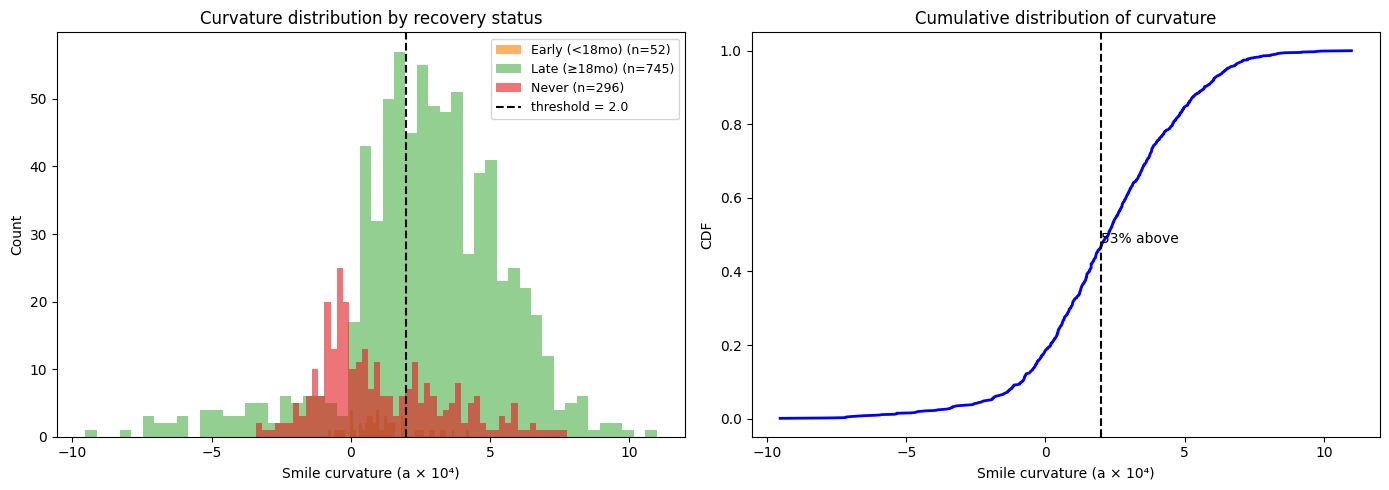

In [12]:
# Curvature distribution plot + cross-tab with recovery status

recovery_det["rec_status"] = np.where(
    recovery_det["recovery_months_post_fire"].isna(), "Never",
    np.where(recovery_det["recovery_months_post_fire"] < 18, "Early (<18mo)", "Late (≥18mo)")
)
print("Smile validity × recovery status:")
print(pd.crosstab(recovery_det["rec_status"], recovery_det["smile_valid"],
                  margins=True).rename(columns={True: "Valid", False: "Invalid"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = {"Early (<18mo)": "#ff7f00", "Late (≥18mo)": "#4daf4a", "Never": "#e41a1c"}
for status in ["Early (<18mo)", "Late (≥18mo)", "Never"]:
    sub = recovery_det[recovery_det["rec_status"] == status]
    ax.hist(sub["smile_curvature"].dropna(), bins=50, alpha=0.6,
            label=f"{status} (n={len(sub)})", color=colors[status])
ax.axvline(CURVATURE_THRESHOLD, color="k", ls="--", lw=1.5,
           label=f"threshold = {CURVATURE_THRESHOLD}")
ax.set_xlabel("Smile curvature (a × 10⁴)")
ax.set_ylabel("Count")
ax.set_title("Curvature distribution by recovery status")
ax.legend(fontsize=9)

ax2 = axes[1]
vals = recovery_det["smile_curvature"].dropna().sort_values().values
cdf = np.arange(1, len(vals) + 1) / len(vals)
ax2.plot(vals, cdf, "b-", lw=2)
ax2.axvline(CURVATURE_THRESHOLD, color="k", ls="--", lw=1.5)
frac_above = (vals >= CURVATURE_THRESHOLD).mean()
ax2.annotate(f"{frac_above:.0%} above", xy=(CURVATURE_THRESHOLD, 1 - frac_above),
             fontsize=10, ha="left", va="bottom")
ax2.set_xlabel("Smile curvature (a × 10⁴)")
ax2.set_ylabel("CDF")
ax2.set_title("Cumulative distribution of curvature")

plt.tight_layout()
plt.savefig(DATA_RESULTS / "curvature_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

recovery_det.drop(columns=["rec_status"], inplace=True)


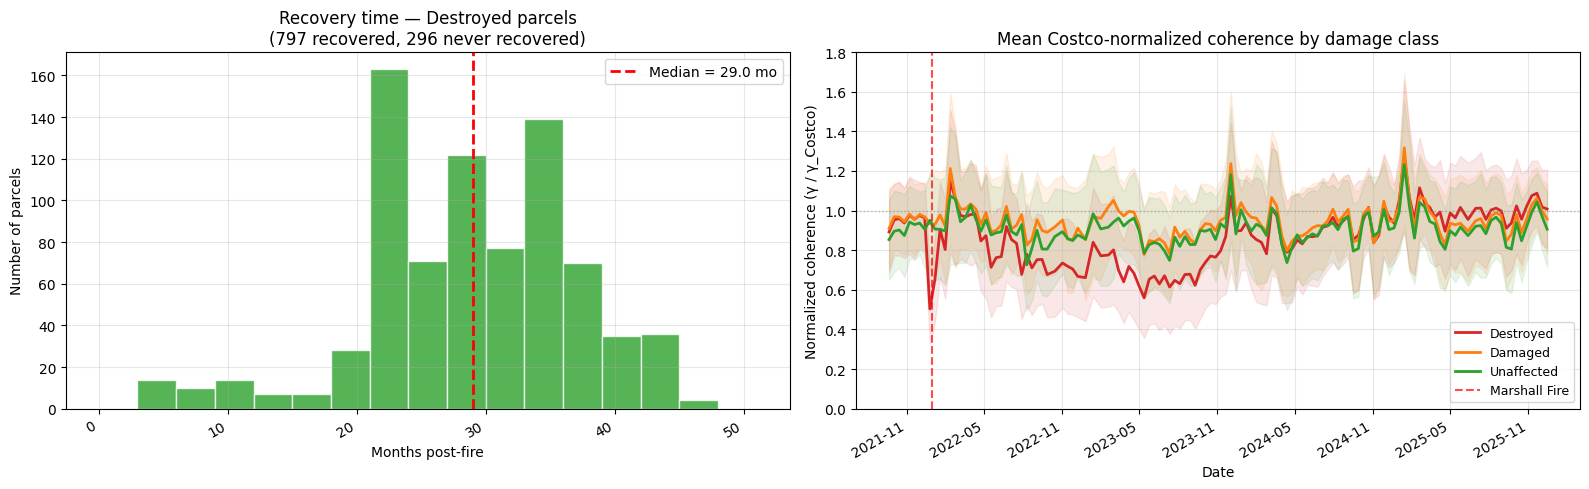

In [13]:
# Plot 1: Histogram of recovery time (months post-fire) for Destroyed parcels
import matplotlib.dates as mdates

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Recovery time histogram
ax = axes[0]
recovered_months = recovery_det["recovery_months_post_fire"].dropna()
ax.hist(recovered_months, bins=np.arange(0, 54, 3), color="#2ca02c", edgecolor="white", alpha=0.8)
ax.axvline(recovered_months.median(), color="red", ls="--", lw=2,
           label=f"Median = {recovered_months.median():.1f} mo")
ax.set_xlabel("Months post-fire")
ax.set_ylabel("Number of parcels")
ax.set_title(f"Recovery time — Destroyed parcels\n"
             f"({n_recovered} recovered, {n_never} never recovered)")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Mean normalized coherence by class over time (NB04c style)
ax = axes[1]
colors_class = {"Destroyed": "#d62728", "Damaged": "#ff7f0e", "Unaffected": "#2ca02c"}

for cond, color in colors_class.items():
    mask = parcels_utm["Condition"] == cond
    class_matrix = norm_matrix[mask.values, :]
    means = np.nanmean(class_matrix, axis=0)
    stds = np.nanstd(class_matrix, axis=0)
    ax.plot(pair_mid_dates, means, "-", color=color, linewidth=2, label=cond)
    ax.fill_between(pair_mid_dates,
                    means - stds, means + stds,
                    color=color, alpha=0.1)

ax.axhline(1.0, color="gray", ls=":", lw=1, alpha=0.5)
ax.axvline(FIRE_DATE, color="red", ls="--", lw=1.5, alpha=0.7, label="Marshall Fire")
ax.set_ylabel("Normalized coherence (γ / γ_Costco)")
ax.set_xlabel("Date")
ax.set_title("Mean Costco-normalized coherence by damage class")
ax.set_ylim(0, 1.8)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [14]:
# Per-parcel recovery plot with ESRI Wayback crop insets

crop_dir = DATA_PROC / "esri_crops"
CROP_BUFFER_DEG = 0.0002

# Wayback release dates (approximate) for x-axis placement
WAYBACK_DATES = {
    "pre":   dt_class(2021, 12, 1),
    "post":  dt_class(2022, 1, 15),
    "17632": dt_class(2023, 8, 1),
    "48925": dt_class(2025, 7, 1),
}
WAYBACK_LABELS = {"pre": "Pre-fire", "post": "Post-fire", "17632": "Aug 2023", "48925": "Jul 2025"}

# Use parcels in 4326 for parcel mask (crops are in lat/lon)
parcels_4326 = gdf.to_crs("EPSG:4326")


def make_parcel_mask(crop_shape, parcel_geom, buffer_deg=CROP_BUFFER_DEG):
    """Create a binary mask of pixels inside the parcel polygon."""
    from shapely.geometry import MultiPolygon

    h, w = crop_shape[:2]
    minx, miny, maxx, maxy = parcel_geom.bounds
    crop_minx = minx - buffer_deg
    crop_miny = miny - buffer_deg
    crop_maxx = maxx + buffer_deg
    crop_maxy = maxy + buffer_deg
    crop_w = crop_maxx - crop_minx
    crop_h = crop_maxy - crop_miny

    mask = np.zeros((h, w), dtype=np.uint8)
    polys = list(parcel_geom.geoms) if isinstance(parcel_geom, MultiPolygon) else [parcel_geom]
    for poly in polys:
        coords = np.array(poly.exterior.coords)
        px_x = ((coords[:, 0] - crop_minx) / crop_w * w).astype(np.int32)
        px_y = ((crop_maxy - coords[:, 1]) / crop_h * h).astype(np.int32)
        cv2.fillPoly(mask, [np.column_stack([px_x, px_y])], 1)
    return mask


def plot_parcel_recovery(parcel_no, ax=None):
    """Plot a single parcel's recovery story with ESRI crop insets."""
    # Find parcel index in parcels_utm
    idx = parcels_utm.index[parcels_utm["ParcelNo"] == parcel_no]
    if len(idx) == 0:
        print(f"Parcel {parcel_no} not found")
        return
    j = parcels_utm.index.get_loc(idx[0])

    series = norm_matrix[j, :]
    det_row = recovery_det[recovery_det["ParcelNo"] == parcel_no]
    rec_date = det_row["recovery_date"].iloc[0] if len(det_row) > 0 else pd.NaT

    # Pre-fire baseline
    pre_vals = series[PRE_FIRE_PAIRS]
    pre_baseline = np.nanmedian(pre_vals)
    threshold = pre_baseline * RECOVERY_THRESHOLD_FRAC

    # Smoothed post-fire series
    post_series = series[fire_pair_idx:]
    smoothed_post = smooth_series(post_series)
    smoothed_full = np.full(n_pairs, np.nan)
    smoothed_full[fire_pair_idx:] = smoothed_post

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 7))
    else:
        fig = ax.figure

    # Raw series (light dots) + smoothed trend (bold line)
    ax.scatter(pair_mid_dates, series, s=12, color="#aaa", alpha=0.5, zorder=2, label="Raw")
    ax.plot(pair_mid_dates, smoothed_full, "-", color="#1f77b4", linewidth=2.5, zorder=3, label="Smoothed")

    # Baselines and thresholds
    ax.axhline(pre_baseline, color="navy", ls="--", lw=1.2, alpha=0.6, label=f"Pre-fire baseline ({pre_baseline:.2f})")
    ax.axhline(threshold, color="orange", ls=":", lw=1.2, alpha=0.6, label=f"90% threshold ({threshold:.2f})")
    ax.axvline(FIRE_DATE, color="red", ls="--", lw=1.5, alpha=0.7, label="Fire")

    if pd.notna(rec_date):
        ax.axvline(rec_date, color="green", ls="--", lw=2, alpha=0.7,
                   label=f"Recovery ({rec_date.strftime('%Y-%m')})")

    ax.set_ylim(0, max(2.0, np.nanmax(series) * 1.1))
    ax.set_ylabel("Normalized coherence (γ / γ_Costco)")
    ax.set_xlabel("Date")
    cond = parcels_utm.loc[idx[0], "Condition"] if idx[0] in parcels_utm.index else "?"
    rec_str = rec_date.strftime("%Y-%m") if pd.notna(rec_date) else "Never"
    # Include smile curvature in title
    curv = det_row["smile_curvature"].iloc[0] if len(det_row) > 0 and "smile_curvature" in det_row.columns else np.nan
    curv_str = f", Curvature: {curv:.1f}" if np.isfinite(curv) else ""
    ax.set_title(f"Parcel {parcel_no} ({cond}) — Recovery: {rec_str}{curv_str}", fontsize=11)
    ax.grid(True, alpha=0.3)

    # ESRI Wayback crop insets
    geom_4326 = parcels_4326.loc[parcels_4326["ParcelNo"] == parcel_no].geometry.iloc[0]

    # Convert wayback dates to axis data coordinates for positioning
    date_range = (pair_mid_dates[-1] - pair_mid_dates[0]).days
    inset_width = 0.12
    inset_height = 0.22

    for suffix, wb_date in WAYBACK_DATES.items():
        crop_path = crop_dir / f"{parcel_no}_{suffix}.jpg"
        if not crop_path.exists():
            continue

        crop_img = np.array(Image.open(crop_path))

        # Draw parcel outline on crop
        mask = make_parcel_mask(crop_img.shape, geom_4326)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        crop_annotated = crop_img.copy()
        cv2.drawContours(crop_annotated, contours, -1, (255, 0, 0), 2)

        # Position inset above the time series at the wayback date x-position
        x_frac = (wb_date - pair_mid_dates[0]).days / date_range
        x_frac = np.clip(x_frac, 0.02, 0.88)

        inset_ax = ax.inset_axes([x_frac - inset_width/2, 0.68, inset_width, inset_height])
        inset_ax.imshow(crop_annotated)
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])
        inset_ax.set_title(WAYBACK_LABELS[suffix], fontsize=7, pad=2)
        for spine in inset_ax.spines.values():
            spine.set_edgecolor("#666")

        ax.axvline(wb_date, color="#999", ls=":", lw=0.8, alpha=0.4, ymin=0, ymax=0.65)

    ax.legend(loc="lower left", fontsize=8, ncol=2)
    return ax

Example parcels:
  157724029011 — Fast recovery (5.7 months)
  157724030010 — Fast recovery (5.7 months)
  157507321009 — Slow recovery (44.0 months)
  157712300005 — Slow recovery (44.0 months)
  157712309005 — Never recovered (never)
  157518245020 — Never recovered (never)


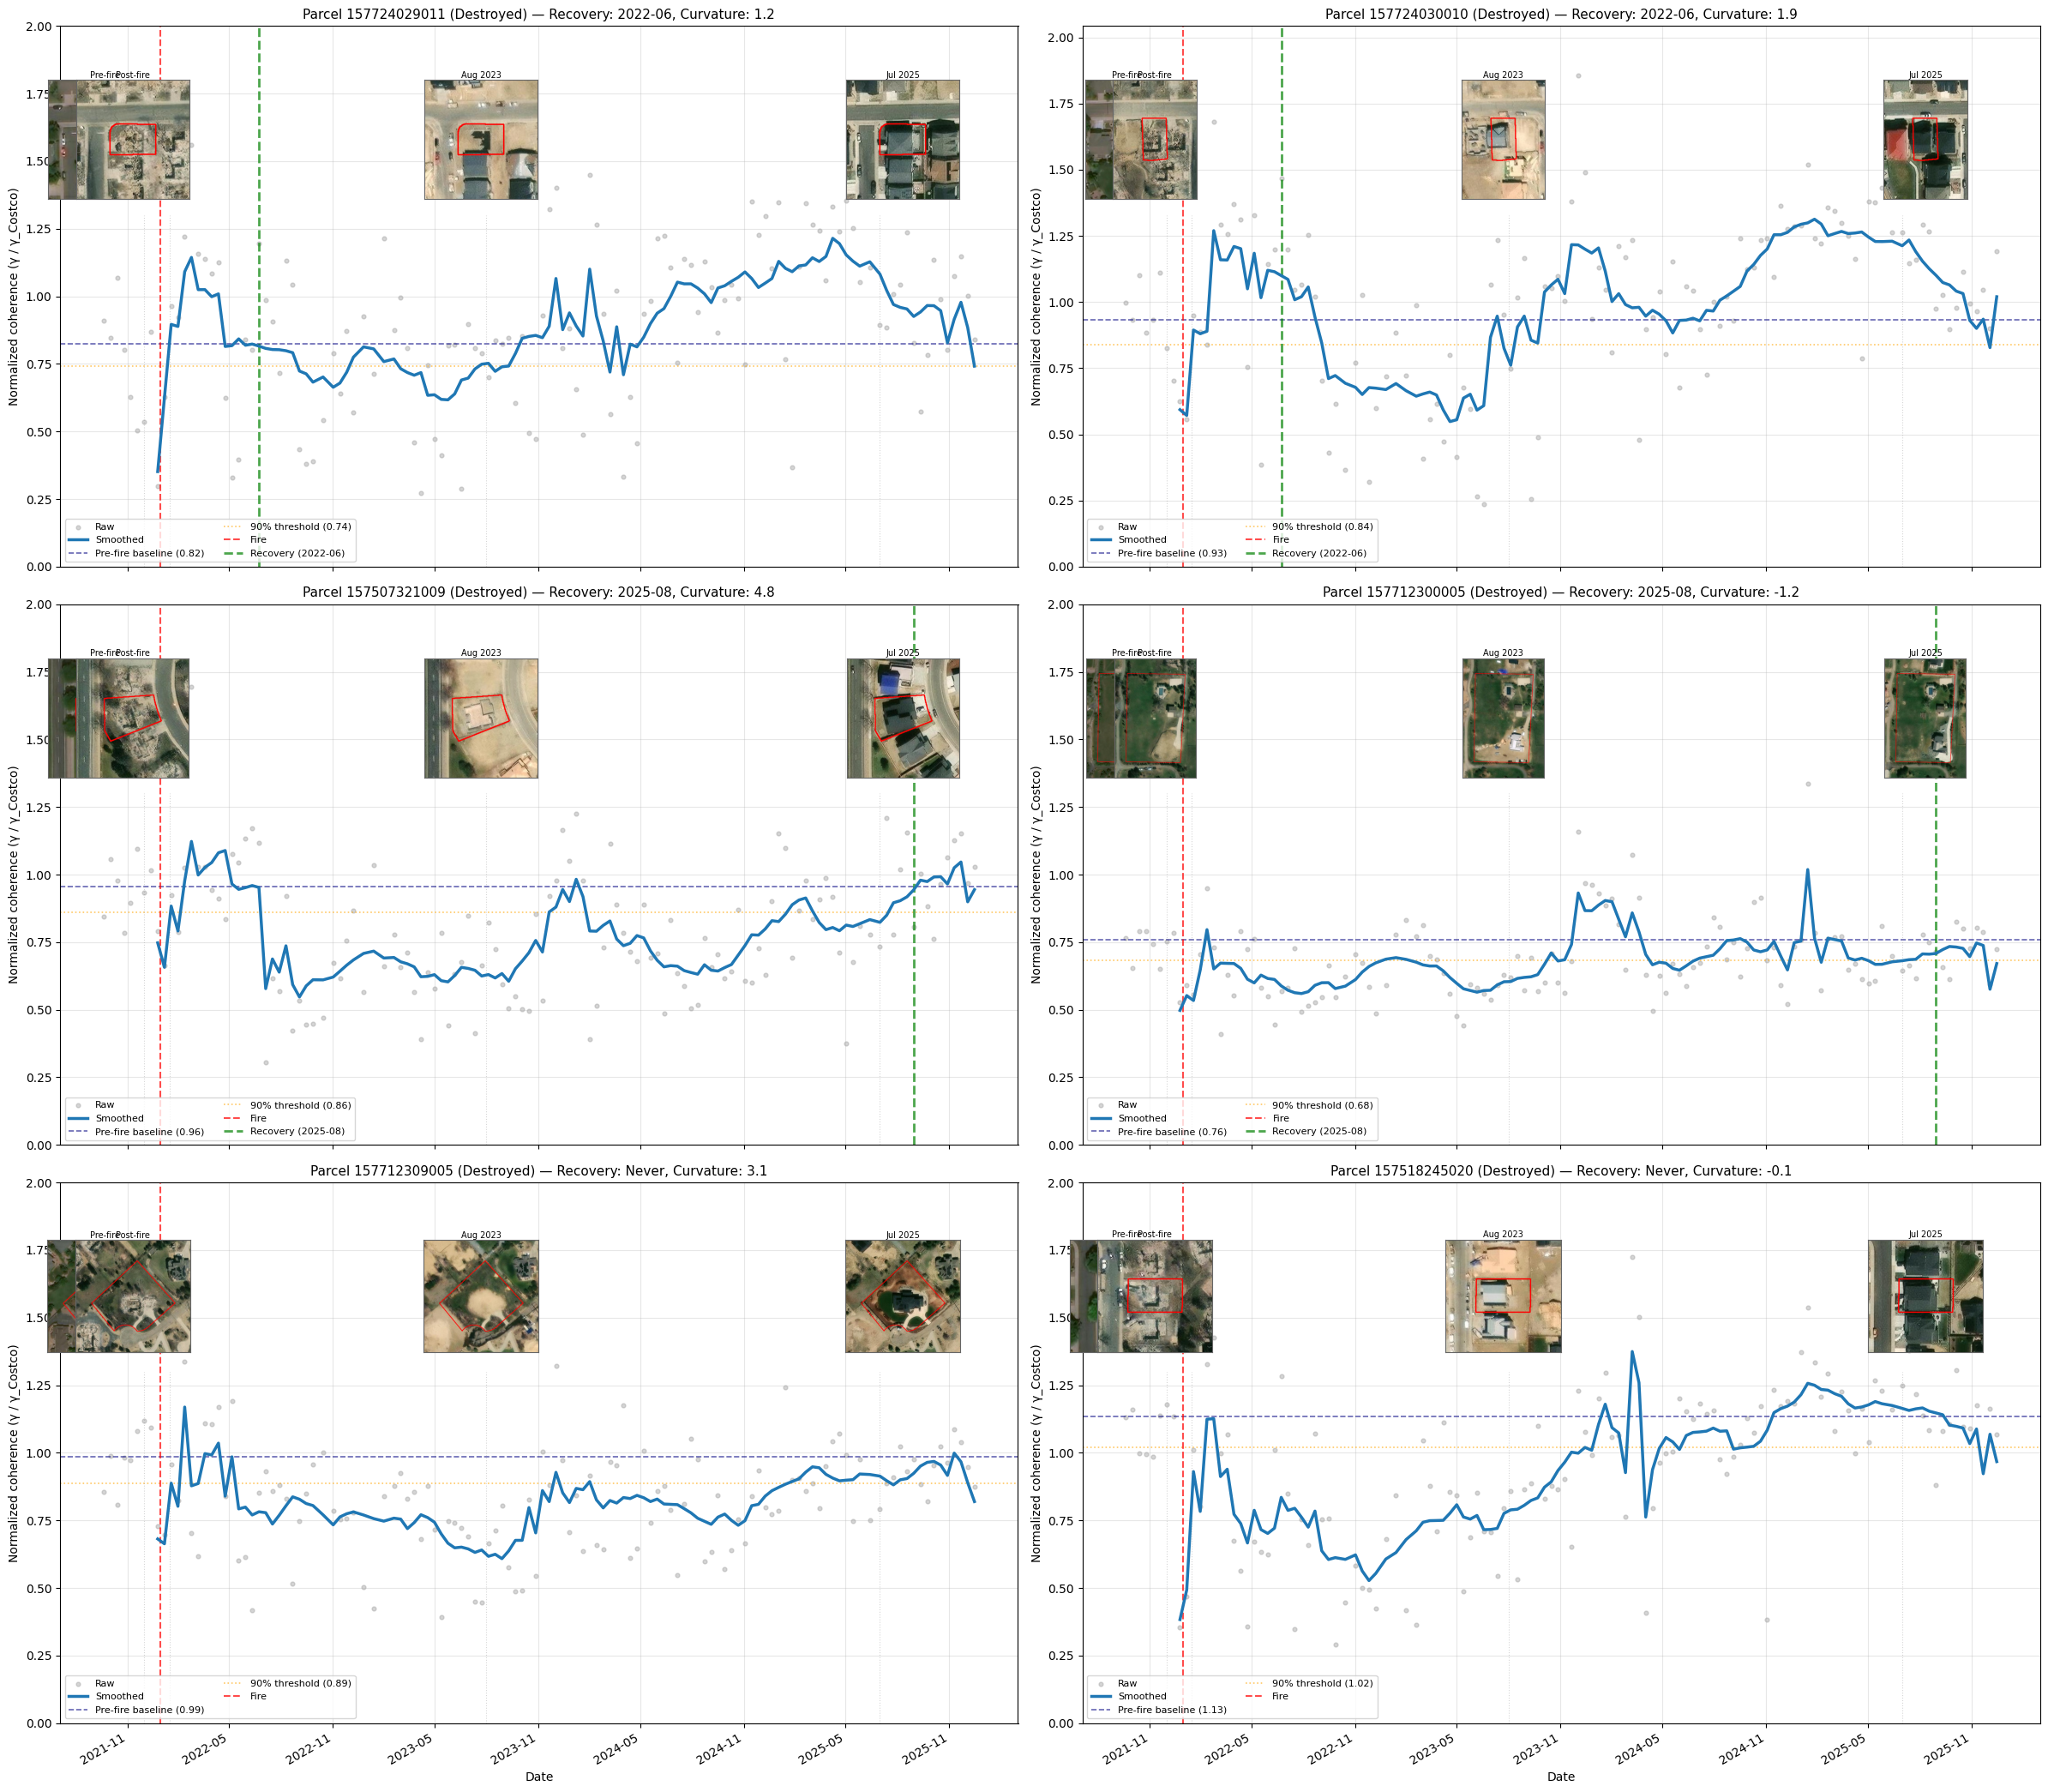

In [15]:
# Show 6 example parcels: 2 fast recovery, 2 slow recovery, 2 never-recovered

recovered_df = recovery_det.dropna(subset=["recovery_months_post_fire"]).sort_values("recovery_months_post_fire")
never_df = recovery_det[recovery_det["recovery_date"].isna()]

# Pick examples (avoiding parcels with no ESRI crops)
def has_crops(pno):
    return (crop_dir / f"{pno}_pre.jpg").exists() and (crop_dir / f"{pno}_post.jpg").exists()

fast_parcels = [p for p in recovered_df.head(20)["ParcelNo"] if has_crops(p)][:2]
slow_parcels = [p for p in recovered_df.tail(20)["ParcelNo"] if has_crops(p)][:2]
never_parcels = [p for p in never_df["ParcelNo"] if has_crops(p)][:2]

example_parcels = fast_parcels + slow_parcels + never_parcels
labels = ["Fast recovery"] * 2 + ["Slow recovery"] * 2 + ["Never recovered"] * 2

print(f"Example parcels:")
for p, l in zip(example_parcels, labels):
    det = recovery_det[recovery_det["ParcelNo"] == p]
    months = det["recovery_months_post_fire"].iloc[0] if len(det) else np.nan
    print(f"  {p} — {l} ({months:.1f} months)" if np.isfinite(months) else f"  {p} — {l} (never)")

fig, axes = plt.subplots(3, 2, figsize=(24, 21))
for ax, pno in zip(axes.flat, example_parcels):
    plot_parcel_recovery(pno, ax=ax)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 3 — Visual Recovery via ESRI Wayback

In [16]:
# Tile utility functions (from notebook 08)
def latlon_to_tile(lat, lon, zoom):
    """Convert lat/lon to WMTS tile coordinates."""
    n = 2 ** zoom
    x = int((lon + 180) / 360 * n)
    y = int((1 - math.log(math.tan(math.radians(lat)) + 1 / math.cos(math.radians(lat))) / math.pi) / 2 * n)
    return x, y


def tile_to_latlon(x, y, zoom):
    """Convert WMTS tile corner to lat/lon (top-left of tile)."""
    n = 2 ** zoom
    lon = x / n * 360 - 180
    lat = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))
    return lat, lon


def fetch_tile(release_num, zoom, tx, ty):
    """Fetch a single WMTS tile as numpy array (RGB)."""
    url = (
        f"https://wayback.maptiles.arcgis.com/arcgis/rest/services/"
        f"World_Imagery/WMTS/1.0.0/default028mm/MapServer/tile/"
        f"{release_num}/{zoom}/{ty}/{tx}"
    )
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    img = Image.open(io.BytesIO(resp.content)).convert("RGB")
    return np.array(img)


def download_parcel_crop(parcel_geom, release_num, zoom=19, buffer_deg=0.0002):
    """Download and mosaic tiles covering a parcel, return cropped RGB array."""
    minx, miny, maxx, maxy = parcel_geom.bounds
    minx -= buffer_deg; miny -= buffer_deg
    maxx += buffer_deg; maxy += buffer_deg

    tx_min, ty_max = latlon_to_tile(miny, minx, zoom)
    tx_max, ty_min = latlon_to_tile(maxy, maxx, zoom)

    rows = []
    for ty in range(ty_min, ty_max + 1):
        row_tiles = []
        for tx in range(tx_min, tx_max + 1):
            tile = fetch_tile(release_num, zoom, tx, ty)
            row_tiles.append(tile)
        rows.append(np.concatenate(row_tiles, axis=1))
    mosaic = np.concatenate(rows, axis=0)

    tl_lat, tl_lon = tile_to_latlon(tx_min, ty_min, zoom)
    br_lat, br_lon = tile_to_latlon(tx_max + 1, ty_max + 1, zoom)

    h, w = mosaic.shape[:2]
    px_left = int((minx - tl_lon) / (br_lon - tl_lon) * w)
    px_right = int((maxx - tl_lon) / (br_lon - tl_lon) * w)
    px_top = int((tl_lat - maxy) / (tl_lat - br_lat) * h)
    px_bottom = int((tl_lat - miny) / (tl_lat - br_lat) * h)

    px_left = max(0, px_left); px_top = max(0, px_top)
    px_right = min(w, px_right); px_bottom = min(h, px_bottom)

    return mosaic[px_top:px_bottom, px_left:px_right]


print("Tile functions defined.")

Tile functions defined.


In [17]:
# ESRI Wayback release numbers for each observation date
ESRI_RELEASES = {
    "pre": 26120,       # 2021-12 pre-fire
    "2022-01": 7110,    # post-fire
    "2022-06": 7110,    # same release (closest available)
    "2023-06": 17632,   # 2023-08 mid-recovery
    "2024-06": 48925,   # 2025-07 late-recovery
}

# Only need to download releases 17632 and 48925 — pre (26120) and post (7110) already cached
NEW_RELEASES = {17632, 48925}

crop_dir = DATA_PROC / "esri_crops"
crop_dir.mkdir(parents=True, exist_ok=True)

parcels_4326 = gdf.to_crs("EPSG:4326")
n_total = len(parcels_4326)
n_downloaded, n_skipped, n_failed = 0, 0, 0

for i, (_, row) in enumerate(parcels_4326.iterrows()):
    pass #skip
    pno = row["ParcelNo"]
    for release in NEW_RELEASES:
        out_path = crop_dir / f"{pno}_{release}.jpg"
        if out_path.exists():
            n_skipped += 1
            continue
        try:
            crop = download_parcel_crop(row.geometry, release)
            Image.fromarray(crop).save(out_path, quality=90)
            n_downloaded += 1
        except Exception as e:
            n_failed += 1
            if n_failed <= 5:
                print(f"  FAIL {pno}/{release}: {e}")
    if (i + 1) % 200 == 0:
        print(f"  [{i+1}/{n_total}] downloaded={n_downloaded}, skipped={n_skipped}, failed={n_failed}")
    time.sleep(0.1)

print(f"\nDone: downloaded={n_downloaded}, skipped={n_skipped}, failed={n_failed}")
print(f"Total crops on disk: {len(list(crop_dir.glob('*.jpg')))}")

  [200/1793] downloaded=0, skipped=400, failed=0
  [400/1793] downloaded=0, skipped=800, failed=0
  [600/1793] downloaded=0, skipped=1200, failed=0
  [800/1793] downloaded=0, skipped=1600, failed=0
  [1000/1793] downloaded=0, skipped=2000, failed=0
  [1200/1793] downloaded=0, skipped=2400, failed=0
  [1400/1793] downloaded=0, skipped=2800, failed=0
  [1600/1793] downloaded=0, skipped=3200, failed=0

Done: downloaded=0, skipped=3586, failed=0
Total crops on disk: 7232


In [18]:
# Compute visual recovery via laplacian variance ratio (masked to parcel polygon)
# Within the parcel boundary: bare dirt/vacant lots have LOW laplacian (smooth ground),
# buildings have HIGH laplacian (sharp rooflines, walls, windows).
# Ratio: visual_recovery = lap_t / lap_pre → low when ground is bare, ~1.0 when structure present.
# Clipped to [0, 1] — values >1 (new construction sharper than original) count as fully recovered.

CROP_BUFFER_DEG = 0.0002  # must match download_parcel_crop buffer_deg


def make_parcel_mask(crop_shape, parcel_geom, buffer_deg=CROP_BUFFER_DEG):
    """Create a binary mask of pixels inside the parcel polygon."""
    from shapely.geometry import MultiPolygon

    h, w = crop_shape[:2]
    minx, miny, maxx, maxy = parcel_geom.bounds
    crop_minx = minx - buffer_deg
    crop_miny = miny - buffer_deg
    crop_maxx = maxx + buffer_deg
    crop_maxy = maxy + buffer_deg

    crop_w = crop_maxx - crop_minx
    crop_h = crop_maxy - crop_miny

    mask = np.zeros((h, w), dtype=np.uint8)

    if isinstance(parcel_geom, MultiPolygon):
        polys = list(parcel_geom.geoms)
    else:
        polys = [parcel_geom]

    for poly in polys:
        coords = np.array(poly.exterior.coords)
        px_x = ((coords[:, 0] - crop_minx) / crop_w * w).astype(np.int32)
        px_y = ((crop_maxy - coords[:, 1]) / crop_h * h).astype(np.int32)
        pts = np.column_stack([px_x, px_y])
        cv2.fillPoly(mask, [pts], 1)

    return mask


def compute_laplacian_var_masked(crop, mask):
    """Compute laplacian variance within masked region only."""
    gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    masked_vals = lap[mask == 1]
    if len(masked_vals) == 0:
        return 0.0
    return float(masked_vals.var())


# Map each observation date to the file suffix used for that release's crop
DATE_TO_SUFFIX = {
    "2022-01": "post",     # release 7110 saved as _post.jpg
    "2022-06": "post",     # same release 7110
    "2023-06": "17632",    # new download
    "2024-06": "48925",    # new download
}

visual_records = []
n_computed, n_missing = 0, 0
parcels_4326 = gdf.to_crs("EPSG:4326")

for i, (_, row) in enumerate(parcels_4326.iterrows()):
    pno = row["ParcelNo"]
    geom = row.geometry
    pre_path = crop_dir / f"{pno}_pre.jpg"

    if not pre_path.exists():
        for date_key in OBSERVATION_DATES:
            visual_records.append({"ParcelNo": pno, "date": date_key, "visual_recovery": np.nan})
        n_missing += 1
        continue

    pre_crop = np.array(Image.open(pre_path))
    mask = make_parcel_mask(pre_crop.shape, geom)
    lap_pre = compute_laplacian_var_masked(pre_crop, mask)

    for date_key in OBSERVATION_DATES:
        suffix = DATE_TO_SUFFIX[date_key]
        crop_path = crop_dir / f"{pno}_{suffix}.jpg"

        if not crop_path.exists():
            visual_records.append({"ParcelNo": pno, "date": date_key, "visual_recovery": np.nan})
            continue

        try:
            date_crop = np.array(Image.open(crop_path))
            if date_crop.shape[:2] != pre_crop.shape[:2]:
                date_mask = cv2.resize(mask, (date_crop.shape[1], date_crop.shape[0]),
                                       interpolation=cv2.INTER_NEAREST)
            else:
                date_mask = mask
            lap_t = compute_laplacian_var_masked(date_crop, date_mask)

            # Non-inverted ratio: structure present (high lap) = high recovery
            # Bare dirt (low lap) = low recovery
            if lap_pre > 1e-6:
                ratio = lap_t / lap_pre
            else:
                ratio = 1.0  # no pre-fire texture → nothing to recover
            ratio = float(np.clip(ratio, 0, 1))
            visual_records.append({"ParcelNo": pno, "date": date_key, "visual_recovery": ratio})
            n_computed += 1
        except Exception as e:
            visual_records.append({"ParcelNo": pno, "date": date_key, "visual_recovery": np.nan})

    if (i + 1) % 500 == 0:
        print(f"  [{i+1}/{len(gdf)}] computed={n_computed}")

visual_df = pd.DataFrame(visual_records)
print(f"\nVisual recovery records: {len(visual_df):,} ({n_computed:,} computed, {n_missing:,} parcels missing pre crop)")

# Print mean visual recovery by class × date
visual_merged = visual_df.merge(gdf[["ParcelNo", "Condition"]], on="ParcelNo", how="left")
print("\nMean visual recovery (masked laplacian variance ratio vs pre) by class × date:")
print(visual_merged.groupby(["Condition", "date"])["visual_recovery"].mean().unstack().round(3))

  [500/1793] computed=2000
  [1000/1793] computed=4000
  [1500/1793] computed=6000

Visual recovery records: 7,172 (7,172 computed, 0 parcels missing pre crop)

Mean visual recovery (masked laplacian variance ratio vs pre) by class × date:
date        2022-01  2022-06  2023-06  2024-06
Condition                                     
Damaged       0.998    0.998    0.997    0.999
Destroyed     0.992    0.992    0.909    0.999
Unaffected    0.999    0.999    0.999    1.000


## 4 — Composite Recovery Score

In [19]:
# Merge NDVI and Costco-normalized InSAR recovery (4-date composite — backward compat)
# NOTE: The primary recovery signal is now the full 126-pair time series + change detection
# (cells above). This 4-date composite is retained for backward compatibility with the
# existing pipeline/frontend that expects recovery_scores.parquet.

# Build insar_df from the 4 observation dates using the full time series
# Map each observation date to the closest coherence pair
from datetime import datetime as _dt
OBS_TO_DATE = {
    "2022-01": _dt(2022, 1, 18),   # midpoint of Jan 12–24
    "2022-06": _dt(2022, 6, 23),   # midpoint of Jun 17–29
    "2023-06": _dt(2023, 6, 18),   # midpoint of Jun 12–24
    "2024-06": _dt(2024, 6, 24),   # midpoint of Jun 18–30
}

# Find nearest pair index for each observation date
obs_pair_idx = {}
for obs_key, obs_date in OBS_TO_DATE.items():
    dists = [abs((mid - obs_date).days) for mid in pair_mid_dates]
    obs_pair_idx[obs_key] = int(np.argmin(dists))
    print(f"  {obs_key} → pair {obs_pair_idx[obs_key]} ({pair_labels[obs_pair_idx[obs_key]]})")

# Build insar_df from the norm_matrix at these 4 pair indices
insar_records = []
for obs_key in OBSERVATION_DATES:
    pidx = obs_pair_idx[obs_key]
    for j, pno in enumerate(parcels_utm["ParcelNo"]):
        val = norm_matrix[j, pidx]
        insar_records.append({
            "ParcelNo": pno,
            "date": obs_key,
            "insar_recovery": float(val) if np.isfinite(val) else np.nan,
        })
insar_df = pd.DataFrame(insar_records)

# Merge with NDVI
recovery_df = ndvi_df.merge(insar_df, on=["ParcelNo", "date"], how="outer")
recovery_df = recovery_df.merge(gdf[["ParcelNo", "Condition"]], on="ParcelNo", how="left")

# Composite: nanmean of NDVI + InSAR
ndvi_vals = recovery_df["ndvi_recovery"].values
insar_vals = recovery_df["insar_recovery"].values
recovery_df["recovery_score"] = np.nanmean(np.column_stack([ndvi_vals, insar_vals]), axis=1)
recovery_df["months_post"] = recovery_df["date"].map(MONTHS_POST)

print(f"Recovery dataframe: {len(recovery_df):,} rows (4-date composite, backward compat)")
print(f"\nComposite recovery score by class × date:")
print(recovery_df.groupby(["Condition", "date"])["recovery_score"].mean().unstack().round(3))

  2022-01 → pair 10 (2022-01-12 → 2022-01-24)
  2022-06 → pair 23 (2022-06-17 → 2022-06-29)
  2023-06 → pair 50 (2023-06-12 → 2023-06-24)
  2024-06 → pair 81 (2024-06-18 → 2024-06-30)
Recovery dataframe: 7,172 rows (4-date composite, backward compat)

Composite recovery score by class × date:
date        2022-01  2022-06  2023-06  2024-06
Condition                                     
Damaged       0.804    1.049    0.975    1.023
Destroyed     0.860    0.935    0.770    0.911
Unaffected    0.865    1.044    0.879    1.036


## 5 — Recovery Trajectory Visualization

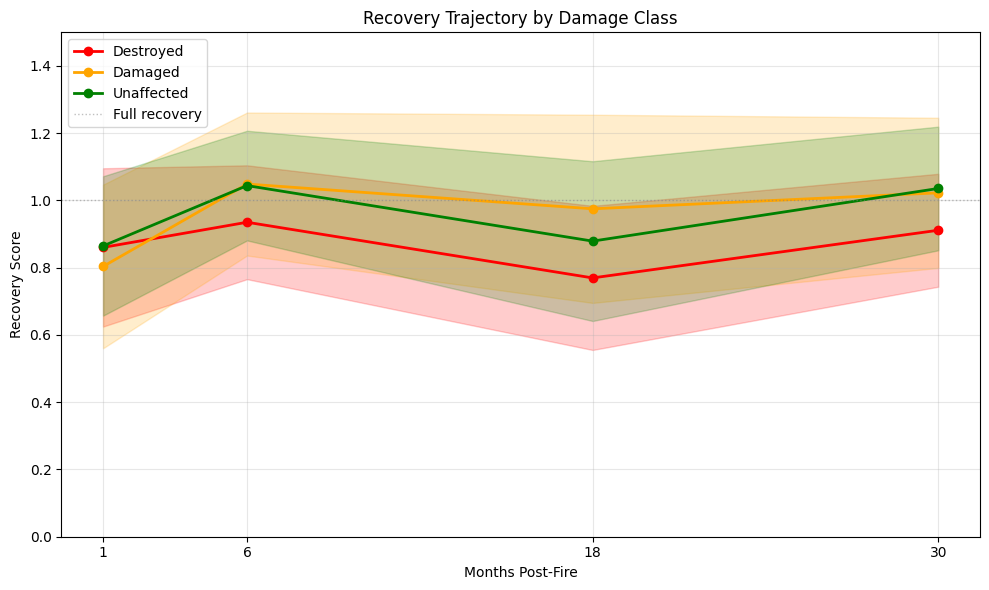

In [20]:
# Mean recovery score by damage class over time with std shading
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"Destroyed": "red", "Damaged": "orange", "Unaffected": "green"}
months = sorted(recovery_df["months_post"].unique())

for condition, color in colors.items():
    subset = recovery_df[recovery_df["Condition"] == condition]
    means = subset.groupby("months_post")["recovery_score"].mean()
    stds = subset.groupby("months_post")["recovery_score"].std()
    ax.plot(means.index, means.values, color=color, label=condition, marker="o", linewidth=2)
    ax.fill_between(
        means.index,
        (means - stds).values,
        (means + stds).values,
        color=color,
        alpha=0.2,
    )

ax.set_xlabel("Months Post-Fire")
ax.set_ylabel("Recovery Score")
ax.set_ylim(0, 1.5)
ax.axhline(1.0, color="gray", ls=":", lw=1, alpha=0.5, label="Full recovery")
ax.set_xticks(months)
ax.set_title("Recovery Trajectory by Damage Class")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

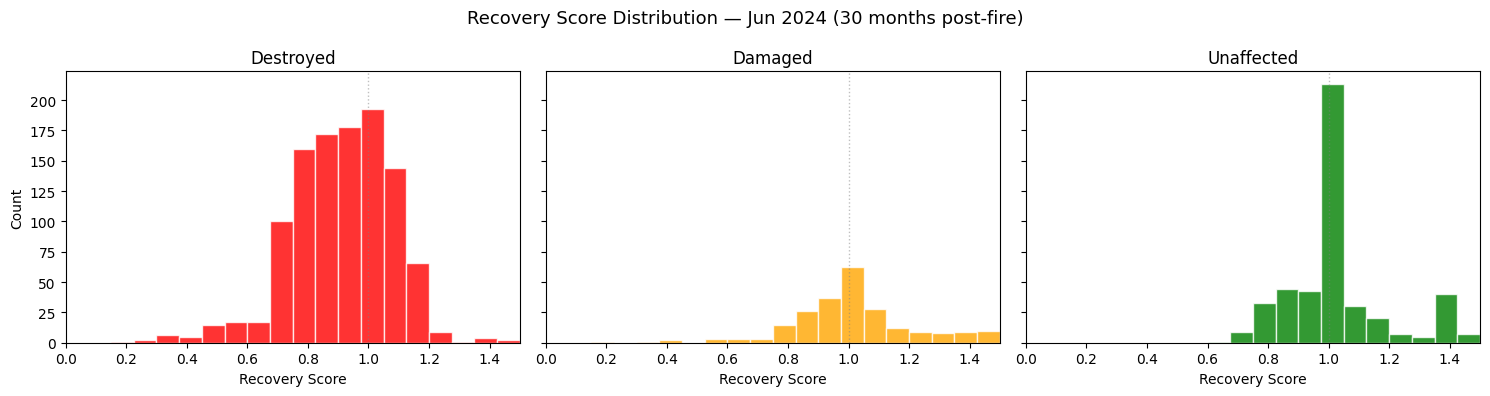

In [21]:
# Recovery score distribution at Jun 2024, faceted by damage class
latest = recovery_df[recovery_df["months_post"] == 30]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = {"Destroyed": "red", "Damaged": "orange", "Unaffected": "green"}

for ax, (condition, color) in zip(axes, colors.items()):
    subset = latest[latest["Condition"] == condition]
    ax.hist(subset["recovery_score"].dropna(), bins=20, range=(0, 1.5),
            color=color, edgecolor="white", alpha=0.8)
    ax.axvline(1.0, color="gray", ls=":", lw=1, alpha=0.5)
    ax.set_title(condition)
    ax.set_xlabel("Recovery Score")
    ax.set_xlim(0, 1.5)

axes[0].set_ylabel("Count")
fig.suptitle("Recovery Score Distribution — Jun 2024 (30 months post-fire)", fontsize=13)
plt.tight_layout()
plt.show()

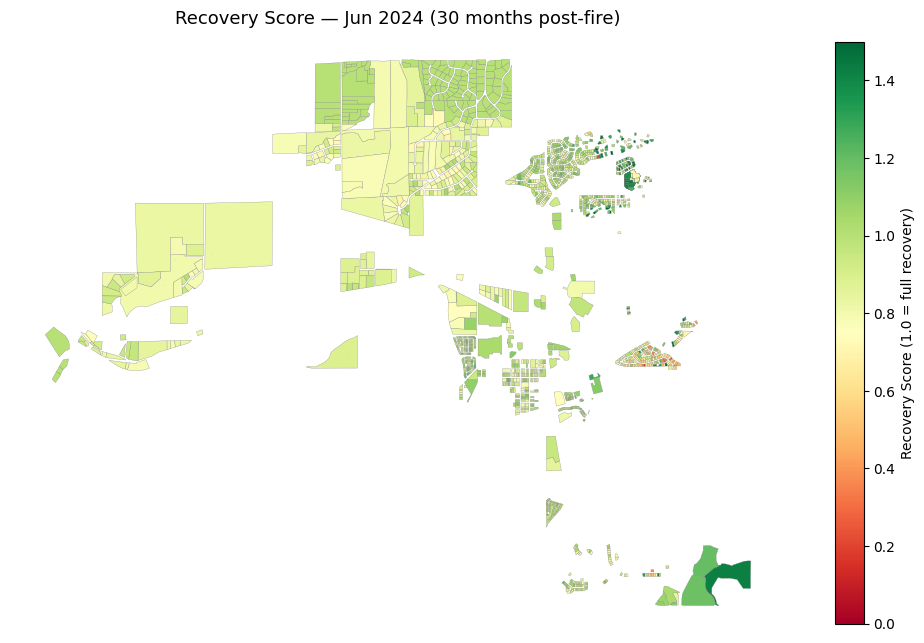

In [22]:
# Map parcels colored by recovery score at Jun 2024
latest_scores = recovery_df[recovery_df["months_post"] == 30][["ParcelNo", "recovery_score"]]
map_gdf = gdf.merge(latest_scores, on="ParcelNo", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
map_gdf.plot(
    column="recovery_score",
    cmap="RdYlGn",
    vmin=0,
    vmax=1.5,
    legend=True,
    legend_kwds={"label": "Recovery Score (1.0 = full recovery)", "shrink": 0.6},
    ax=ax,
    edgecolor="grey",
    linewidth=0.2,
)
ax.set_title("Recovery Score \u2014 Jun 2024 (30 months post-fire)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

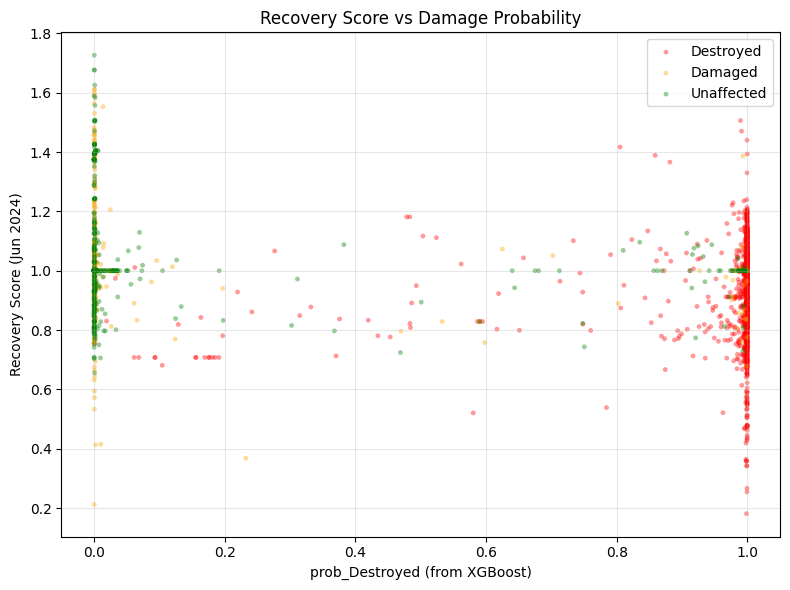

In [23]:
# Scatter: recovery score at Jun 2024 vs damage probability
latest_scores = recovery_df[recovery_df["months_post"] == 30][["ParcelNo", "recovery_score"]]
scatter_df = gdf[["ParcelNo", "Condition", "prob_Destroyed"]].merge(latest_scores, on="ParcelNo", how="inner")

colors_map = {"Destroyed": "red", "Damaged": "orange", "Unaffected": "green"}

fig, ax = plt.subplots(figsize=(8, 6))
for condition, color in colors_map.items():
    subset = scatter_df[scatter_df["Condition"] == condition]
    ax.scatter(subset["prob_Destroyed"], subset["recovery_score"],
               c=color, label=condition, alpha=0.4, s=12, edgecolors="none")

ax.set_xlabel("prob_Destroyed (from XGBoost)")
ax.set_ylabel("Recovery Score (Jun 2024)")
ax.set_title("Recovery Score vs Damage Probability")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6 — Recovery Outliers

In [24]:
# Identify recovery outliers
latest = recovery_df[recovery_df["months_post"] == 30].copy()

# Stalled: Destroyed parcels with recovery < 0.3
stalled = latest[(latest["Condition"] == "Destroyed") & (latest["recovery_score"] < 0.3)]

# Fast: Destroyed parcels with recovery > 0.7
fast = latest[(latest["Condition"] == "Destroyed") & (latest["recovery_score"] > 0.7)]

# Regression: recovery decreased between consecutive dates
recovery_wide = recovery_df.pivot_table(index="ParcelNo", columns="months_post", values="recovery_score")
regression_mask = pd.Series(False, index=recovery_wide.index)
sorted_months = sorted(recovery_wide.columns)
for i in range(1, len(sorted_months)):
    prev, curr = sorted_months[i - 1], sorted_months[i]
    regression_mask = regression_mask | (recovery_wide[curr] < recovery_wide[prev])
regression_parcels = regression_mask[regression_mask].index.tolist()
regression = latest[latest["ParcelNo"].isin(regression_parcels)]

print(f"Stalled (Destroyed, recovery < 0.3): {len(stalled)}")
print(f"Fast recovery (Destroyed, recovery > 0.7): {len(fast)}")
print(f"Regression (decreased between consecutive dates): {len(regression)}")

# Label column for display
addr_col = "SiteAddress" if "SiteAddress" in gdf.columns else None

def show_top(df, label, n=10):
    merged = df.merge(gdf[["ParcelNo"] + ([addr_col] if addr_col else [])], on="ParcelNo", how="left")
    display_cols = [addr_col, "ParcelNo", "recovery_score"] if addr_col else ["ParcelNo", "recovery_score"]
    print(f"\nTop {n} {label}:")
    print(merged[display_cols].head(n).to_string(index=False))

show_top(stalled.sort_values("recovery_score"), "Stalled")
show_top(fast.sort_values("recovery_score", ascending=False), "Fast Recovery")

Stalled (Destroyed, recovery < 0.3): 3
Fast recovery (Destroyed, recovery > 0.7): 1004
Regression (decreased between consecutive dates): 1532

Top 10 Stalled:
    ParcelNo  recovery_score
157519106002        0.180977
157519106013        0.254311
157519108006        0.266618

Top 10 Fast Recovery:
    ParcelNo  recovery_score
157507410019        1.506036
157518409010        1.470394
157530413010        1.439924
157519109019        1.416999
157519105010        1.393318
157519106015        1.388590
157507304006        1.366008
157519106016        1.329710
157507320031        1.239446
157519106011        1.235287


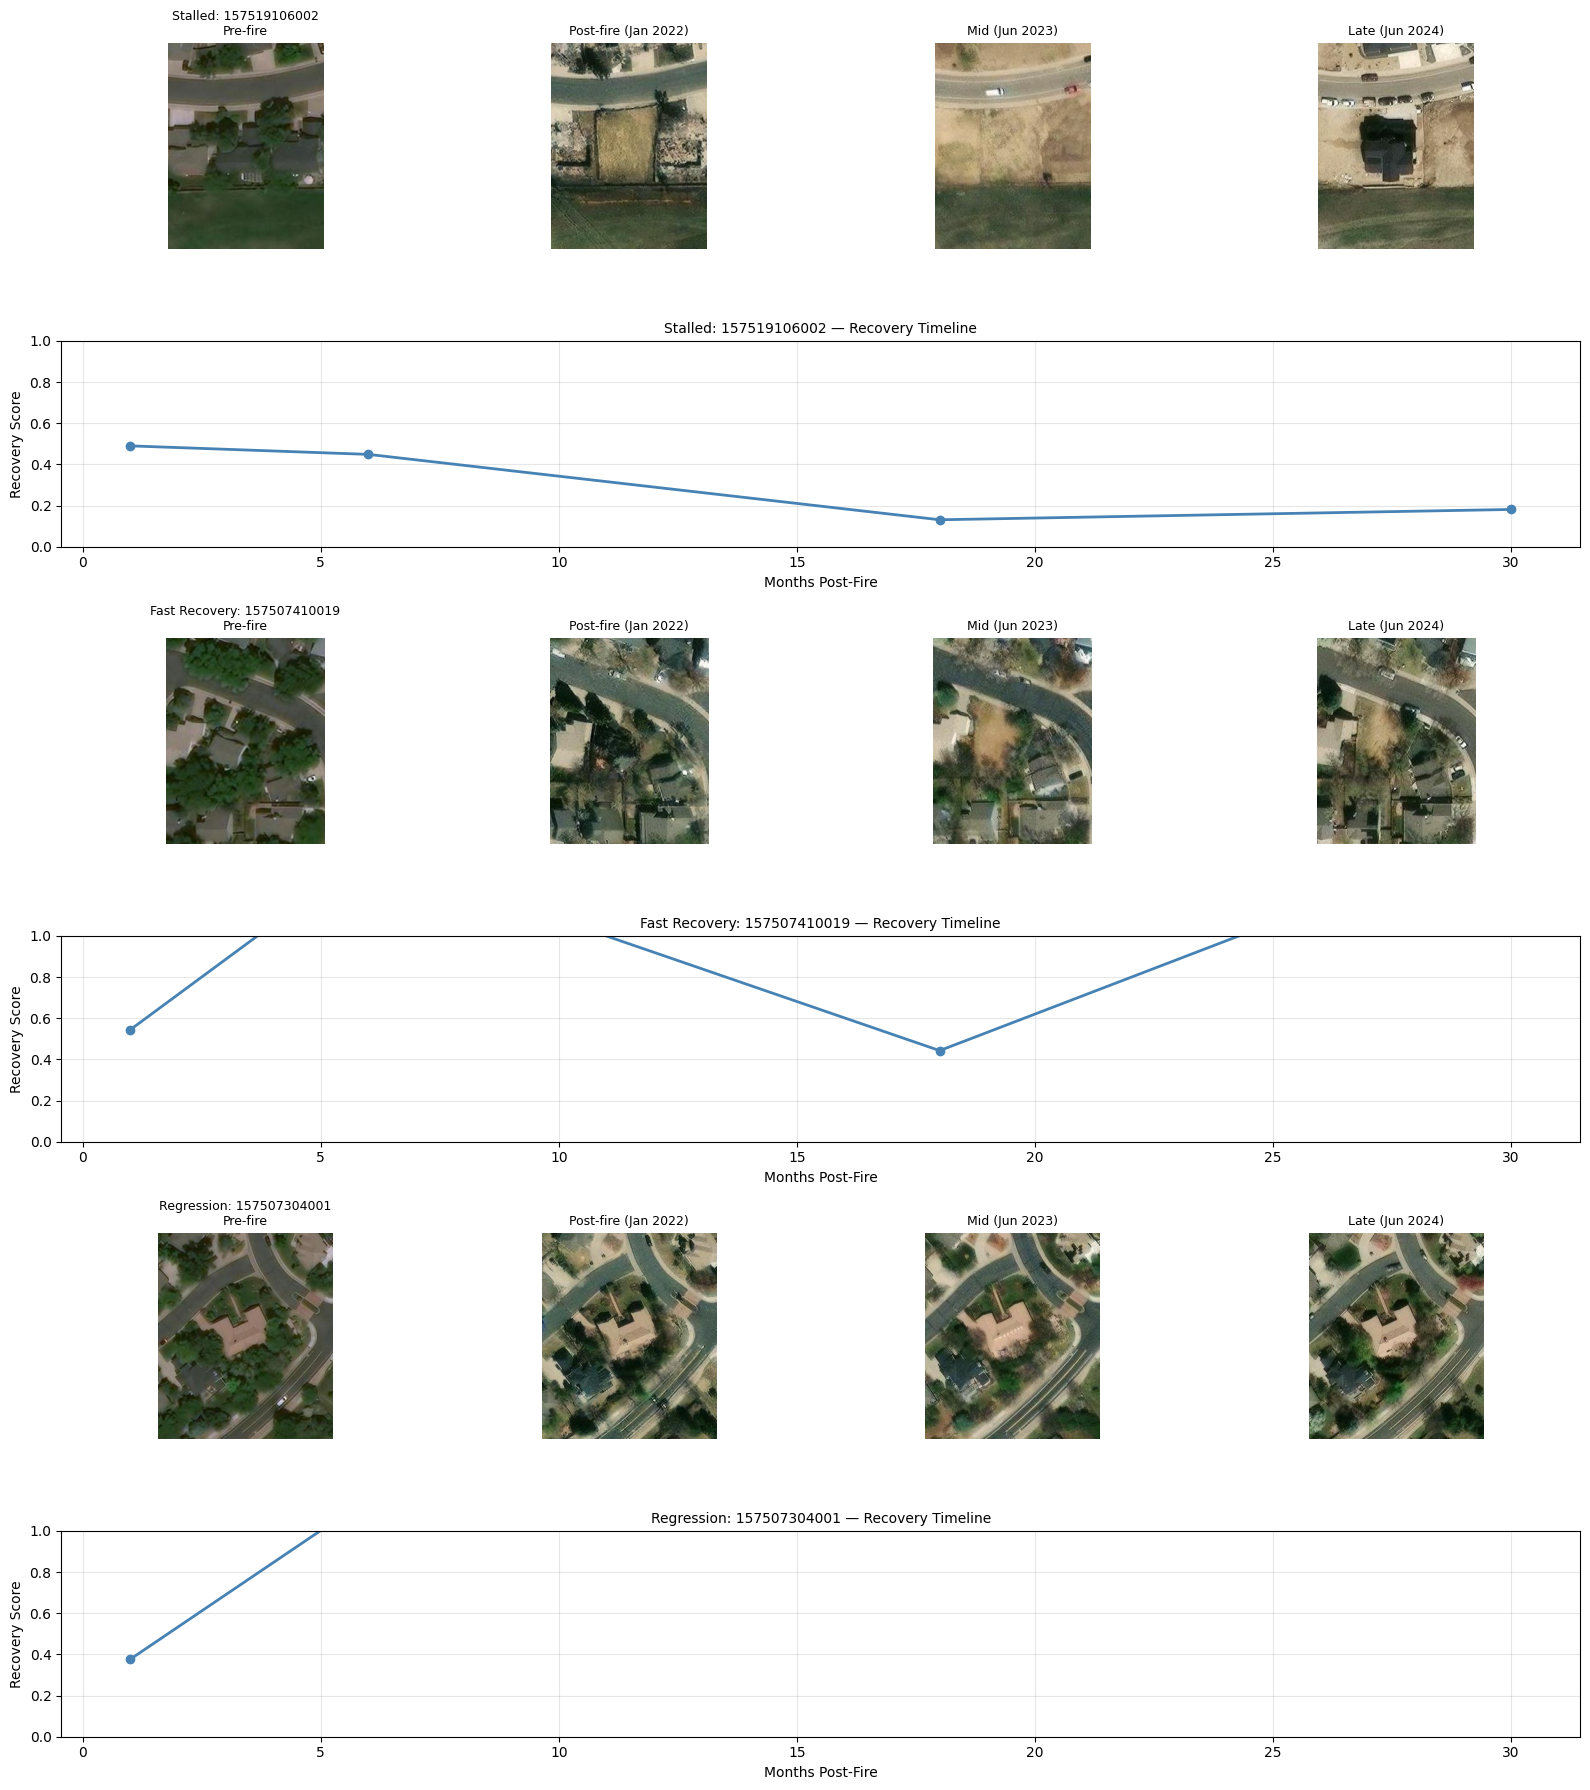

In [25]:
# Visual case studies: 1 stalled, 1 fast, 1 regression parcel
example_stalled = stalled.sort_values("recovery_score").iloc[0]["ParcelNo"] if len(stalled) > 0 else None
example_fast = fast.sort_values("recovery_score", ascending=False).iloc[0]["ParcelNo"] if len(fast) > 0 else None
# Pick a regression parcel that isn't already in stalled/fast
reg_only = [p for p in regression_parcels if p != example_stalled and p != example_fast]
example_regression = reg_only[0] if reg_only else (regression_parcels[0] if regression_parcels else None)

examples = [
    ("Stalled", example_stalled),
    ("Fast Recovery", example_fast),
    ("Regression", example_regression),
]

suffixes = ["pre", "post", "17632", "48925"]
suffix_labels = ["Pre-fire", "Post-fire (Jan 2022)", "Mid (Jun 2023)", "Late (Jun 2024)"]

fig, axes = plt.subplots(len(examples) * 2, 4, figsize=(16, len(examples) * 6))

for idx, (label, parcel_no) in enumerate(examples):
    if parcel_no is None:
        continue
    row_img = idx * 2
    row_plot = idx * 2 + 1

    # Top row: 4 images
    for col, (suffix, slabel) in enumerate(zip(suffixes, suffix_labels)):
        ax = axes[row_img, col]
        img_path = crop_dir / f"{parcel_no}_{suffix}.jpg"
        if img_path.exists():
            img = plt.imread(str(img_path))
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{slabel}" if col > 0 else f"{label}: {parcel_no}\n{slabel}", fontsize=9)
        ax.axis("off")

    # Bottom row: recovery timeline spanning all 4 columns
    ax_line = fig.add_subplot(len(examples) * 2, 1, row_plot + 1)
    parcel_ts = recovery_df[recovery_df["ParcelNo"] == parcel_no].sort_values("months_post")
    ax_line.plot(parcel_ts["months_post"], parcel_ts["recovery_score"], "o-", color="steelblue", linewidth=2)
    ax_line.set_xlabel("Months Post-Fire")
    ax_line.set_ylabel("Recovery Score")
    ax_line.set_ylim(0, 1)
    ax_line.set_title(f"{label}: {parcel_no} — Recovery Timeline", fontsize=10)
    ax_line.grid(True, alpha=0.3)

    # Hide the original subplot axes for the plot row
    for col in range(4):
        axes[row_plot, col].set_visible(False)

plt.tight_layout()
plt.show()

## 7 — Save Artifacts

In [26]:
# Save long-format recovery scores
recovery_long = recovery_df.rename(columns={
    "date": "observation_date",
    "months_post": "months_post_fire",
    "Condition": "damage_class",
})

# Add damage probability from gdf
prob_map = gdf.set_index("ParcelNo")["prob_Destroyed"].to_dict()
recovery_long["damage_prob"] = recovery_long["ParcelNo"].map(prob_map)

# Select and order columns (NDVI + InSAR, no visual)
recovery_long = recovery_long[
    ["ParcelNo", "observation_date", "months_post_fire", "damage_class",
     "damage_prob", "ndvi_recovery", "insar_recovery", "recovery_score"]
]

out_path = DATA_RESULTS / "recovery_scores.parquet"
recovery_long.to_parquet(out_path, index=False)
print(f"Saved {out_path}  ({len(recovery_long)} rows)")
recovery_long.head()

Saved ../data/results/recovery_scores.parquet  (7172 rows)


,ParcelNo,observation_date,months_post_fire,damage_class,damage_prob,ndvi_recovery,insar_recovery,recovery_score
0,157507304001,2022-01,1,Unaffected,0.000228,0.000000,0.753103,0.376552
1,157507304001,2022-06,6,Unaffected,0.000228,1.725736,0.590086,1.157911
2,157507304001,2023-06,18,Unaffected,0.000228,2.000000,0.584167,1.292084
3,157507304001,2024-06,30,Unaffected,0.000228,2.000000,0.574104,1.287052
4,157507304004,2022-01,1,Damaged,0.998953,0.000000,0.665094,0.332547


In [27]:
# Save per-parcel detail JSON files (add recovery_date from change detection)
parcels_dir = DATA_RESULTS / "parcels"
parcels_dir.mkdir(parents=True, exist_ok=True)

# Build recovery lookup
recovery_lookup = recovery_det.set_index("ParcelNo")[["recovery_date", "recovery_months_post_fire"]].to_dict("index")

for parcel_no, group in recovery_long.groupby("ParcelNo"):
    rec_info = recovery_lookup.get(parcel_no, {})
    rec_date = rec_info.get("recovery_date", pd.NaT)
    rec_months = rec_info.get("recovery_months_post_fire", np.nan)

    detail = {
        "ParcelNo": parcel_no,
        "damage_class": group["damage_class"].iloc[0],
        "damage_prob": round(float(group["damage_prob"].iloc[0]), 4),
        "recovery_date": rec_date.strftime("%Y-%m-%d") if pd.notna(rec_date) else None,
        "recovery_months_post_fire": round(float(rec_months), 1) if np.isfinite(rec_months) else None,
        "recovery_timeline": [
            {
                "date": row["observation_date"],
                "months_post_fire": int(row["months_post_fire"]),
                "ndvi_recovery": round(float(row["ndvi_recovery"]), 3) if pd.notna(row["ndvi_recovery"]) else None,
                "insar_recovery": round(float(row["insar_recovery"]), 3) if pd.notna(row["insar_recovery"]) else None,
                "recovery_score": round(float(row["recovery_score"]), 3) if pd.notna(row["recovery_score"]) else None,
            }
            for _, row in group.iterrows()
        ],
        "latest_recovery": round(float(group["recovery_score"].iloc[-1]), 3) if pd.notna(group["recovery_score"].iloc[-1]) else None,
    }
    out_path = parcels_dir / f"{parcel_no}.json"
    with open(out_path, "w") as f:
        json.dump(detail, f, indent=2)

print(f"Saved {len(recovery_long['ParcelNo'].unique())} parcel JSON files to {parcels_dir}")
print(f"  Now includes: recovery_date, recovery_months_post_fire")

Saved 1793 parcel JSON files to ../data/results/parcels
  Now includes: recovery_date, recovery_months_post_fire


In [28]:
# Save recovery_summary.json (with recovery detection stats)
recovery_by_class = {}
for condition in recovery_long["damage_class"].unique():
    recovery_by_class[condition] = {}
    subset = recovery_long[recovery_long["damage_class"] == condition]
    for date in sorted(recovery_long["observation_date"].unique()):
        date_subset = subset[subset["observation_date"] == date]["recovery_score"]
        recovery_by_class[condition][date] = {
            "mean": round(float(date_subset.mean()), 3),
            "std": round(float(date_subset.std()), 3),
            "median": round(float(date_subset.median()), 3),
        }

# Recovery detection stats
rec_months = recovery_det["recovery_months_post_fire"].dropna()
detection_stats = {
    "n_destroyed": int(len(recovery_det)),
    "n_recovered": int(recovery_det["recovery_date"].notna().sum()),
    "n_never_recovered": int(recovery_det["recovery_date"].isna().sum()),
    "median_recovery_months": round(float(rec_months.median()), 1) if len(rec_months) > 0 else None,
    "mean_recovery_months": round(float(rec_months.mean()), 1) if len(rec_months) > 0 else None,
    "method": "Costco-normalized coherence, rolling median w=5, 90% threshold, sustain=3",
}

summary = {
    "n_parcels": int(recovery_long["ParcelNo"].nunique()),
    "observation_dates": sorted(recovery_long["observation_date"].unique().tolist()),
    "recovery_by_class": recovery_by_class,
    "coherence_time_series": {
        "n_pairs": n_pairs,
        "date_range": f"{pair_dates[0][0].strftime('%Y-%m-%d')} to {pair_dates[-1][1].strftime('%Y-%m-%d')}",
        "reference_parcel": COSTCO_PARCEL,
    },
    "recovery_detection": detection_stats,
    "stalled_count": int(len(stalled)) if "stalled" in dir() else detection_stats["n_never_recovered"],
    "fast_recovery_count": int(len(fast)) if "fast" in dir() else int((rec_months < 6).sum()),
}

summary_path = DATA_RESULTS / "recovery_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved {summary_path}")
print(f"  Parcels: {summary['n_parcels']}")
print(f"  Recovery detection: {detection_stats['n_recovered']} recovered, "
      f"{detection_stats['n_never_recovered']} never, "
      f"median {detection_stats['median_recovery_months']} months")

Saved ../data/results/recovery_summary.json
  Parcels: 1793
  Recovery detection: 797 recovered, 296 never, median 29.0 months


## 8 — Conclusions

**Full InSAR Time Series + Recovery Detection:**

This notebook replaces the original 4-date InSAR snapshot approach with the **full 126-pair
Costco-normalized coherence time series** (Sep 2021 → Dec 2025), enabling per-parcel
recovery date detection.

### Method
1. **126 consecutive 12-day coherence pairs** computed from OPERA CSLC (Sentinel-1, Track T056)
2. **Costco normalization** (γ / γ_Costco) removes environmental noise (seasonal, orbital, weather)
3. **Change detection** identifies per-parcel recovery: rolling median (w=5), 90% of pre-fire
   baseline threshold, sustained for ≥3 consecutive pairs

### Key Findings
- **Pre-fire:** All classes at ~0.90–0.95× Costco coherence
- **Fire event:** Destroyed drops to ~0.50× in one 12-day revisit (Dec 19→31, 2021)
- **Recovery detection:** Identifies when each destroyed parcel's coherence returns to
  pre-fire levels, with per-parcel recovery dates and months-post-fire
- **Coherence overshoot:** Many rebuilt parcels exceed 1.0× Costco (new fire-hardened
  construction, minimal landscaping, cleaner radar facets)

### Outputs
- **`coherence_timeseries.parquet`** — Full per-parcel × pair time series (~199K rows)
- **`recovery_detection.parquet`** — Per-parcel recovery date for all Destroyed parcels
- **`recovery_scores.parquet`** — 4-date NDVI+InSAR composite (backward compatibility)
- **Per-parcel JSON** — Updated with `recovery_date` and `recovery_months_post_fire`
- **`recovery_summary.json`** — Updated with recovery detection statistics

### Limitations
- **Coherence noise:** Individual pairs are noisy; rolling median smoothing mitigates but
  may delay detection by 2-3 pairs (~24-36 days)
- **Threshold sensitivity:** 90% recovery threshold is conservative; some parcels may
  functionally recover at lower coherence if pre-fire baseline was high
- **Costco reference:** Assumes parking lot is stable (confirmed in NB04c across full arc)
- **NDVI resolution:** Landsat 30m still averages over parcels; InSAR at 5×10m is finer

## Frontend Integration Notes

- **`recovery_scores.parquet`** feeds into the dbt pipeline as a new staging model
  (`stg_recovery_scores`), joining with parcel geometries and damage classifications in the
  intermediate layer.
- **Per-parcel JSON** files at `data/results/parcels/{ParcelNo}.json` are directly consumable
  by the frontend API layer — no transformation needed.
- **Map coloring:** The recovery score drives a red-to-yellow-to-green (RdYlGn) gradient on the
  parcel map, giving an immediate visual indicator of recovery status.
- **Timeline charts:** On parcel click, the frontend renders a per-parcel recovery trajectory
  chart from the `recovery_timeline` array in the JSON detail file.
- **Scrollytelling narrative:** Outlier parcels (stalled and fast recovery) serve as compelling
  case studies in the scrollytelling flow, illustrating the uneven pace of disaster recovery.